In [4]:
# dataset load
import pandas as pd
DATA_PATH = "student_mental_health_burnout_1M.csv"
df_1m :pd.DataFrame = pd.read_csv(DATA_PATH)
df_1m[:100]

,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,23,Male,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,Low,1.746601
1,20,Male,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,Low,0.000000
2,29,Male,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,Low,0.696941
3,27,Male,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,High,5.380592
4,24,Male,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,Low,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,29,Female,3,5.375062,5.338316,80.982024,5.759744,4.271680,3.533563,7.312874,2.980812,3.908400,7.057710,8.622998,9.713833,5.988744,2.950994,5.354529,Low,4.174980
96,18,Female,3,7.958061,9.502525,75.987530,6.433656,3.728825,1.373351,8.517508,2.637354,6.348850,5.133156,4.177367,5.851558,8.886635,2.670052,5.895885,Low,3.365640
97,21,Female,4,8.706658,7.597969,77.639096,7.092993,5.946303,3.397777,5.425566,2.366063,4.963052,4.937139,6.214089,5.486136,8.515191,3.597517,4.359579,Medium,1.732625
98,24,Female,4,6.371529,5.788810,71.993119,4.895763,4.286411,1.329208,4.521030,3.077423,6.007947,4.227321,4.804397,3.157183,9.168905,2.384478,6.357009,Low,0.020018


In [6]:
# just discerning features types
discrete_feats :list[str] = ["age", "academic_year"]
continuous_feats :list[str] = ["study_hours_per_day", "exam_pressure", "academic_performance", "stress_level", "anxiety_score", 
                    "depression_score", "sleep_hours", "physical_activity", "social_support", "screen_time", "internet_usage",
                    "financial_stress", "family_expectation", "burnout_score", "mental_health_index", "dropout_risk"]
num_feats :list[str]= discrete_feats + continuous_feats
cat_feats :list[str] = ["gender", "risk_level"]

## General info

In [ ]:
null_per_row :pd.Series = df_1m.isnull().mean(axis=1) * 100
print(f"Rows with any missing values: {(null_per_row > 0).sum()}")

Rows with any missing values: 0


In [ ]:
df_1m.describe()

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,dropout_risk
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,22.996456,2.500782,5.001727,5.998810,70.999135,4.246462,2.986413,1.274728,6.501713,3.011153,4.999724,5.018766,5.038116,5.002920,5.983287,1.784073,7.023073,1.324896
std,3.742579,1.117749,1.989340,1.548268,5.660073,1.678998,1.509844,1.221273,1.472972,1.463679,1.976536,1.960599,2.157838,1.976426,1.960972,1.664035,1.310698,1.342727
min,17.000000,1.000000,0.000000,1.000000,42.365714,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.309745,0.000000
25%,20.000000,2.000000,3.650644,4.944647,67.180912,3.102593,1.923747,0.005198,5.491047,1.990596,3.650029,3.651138,3.491114,3.656767,4.647065,0.124810,6.141553,0.000000
50%,23.000000,3.000000,4.998222,5.998906,70.999914,4.244029,2.969514,1.047839,6.501938,3.000619,4.999017,5.003518,5.001542,5.001279,5.999517,1.496505,7.074414,1.009531
75%,26.000000,4.000000,6.345532,7.051914,74.820937,5.385464,4.014996,2.086397,7.514642,4.011208,6.349751,6.351386,6.506834,6.354571,7.351578,2.889473,7.962169,2.173661
max,29.000000,4.000000,14.000000,10.000000,97.246309,10.000000,10.000000,8.530800,10.000000,7.000000,10.000000,12.000000,14.000000,10.000000,10.000000,10.000000,10.000000,9.326226


## Kurtosis and skewness

In [ ]:
from scipy.stats import kurtosis, skew

kurt_skew_res :list[dict[str, float|str]] = []
for n in num_feats:
    # for this statistics there are the library functions
    k = kurtosis(df_1m[n])
    s = skew(df_1m[n])
    kurt_skew_res.append({'variable': n, 'kurtosis': k, 'skewness': s})

ks_df = pd.DataFrame(kurt_skew_res)
ks_df

,variable,kurtosis,skewness
0,age,-1.214538,0.002343
1,academic_year,-1.359344,-0.001231
2,study_hours_per_day,-0.118196,0.041091
3,exam_pressure,-0.160715,-0.015144
4,academic_performance,-0.002222,-0.001448
5,stress_level,-0.144543,0.032258
6,anxiety_score,-0.284392,0.146255
7,depression_score,0.093713,0.835118
8,sleep_hours,-0.325809,-0.001419
9,physical_activity,-0.345664,0.094178


Comments:
- skeweness (using ±1 threshold): all features pretty balanced, except _depression score, burnout score_ and _droupout risk_.
- kurtosis: nothing to be noticed, more or less all features have tails of the same weight as gaussian

Note that these asymmetries might influence linear models but not XGBoost.

## Features std deviation

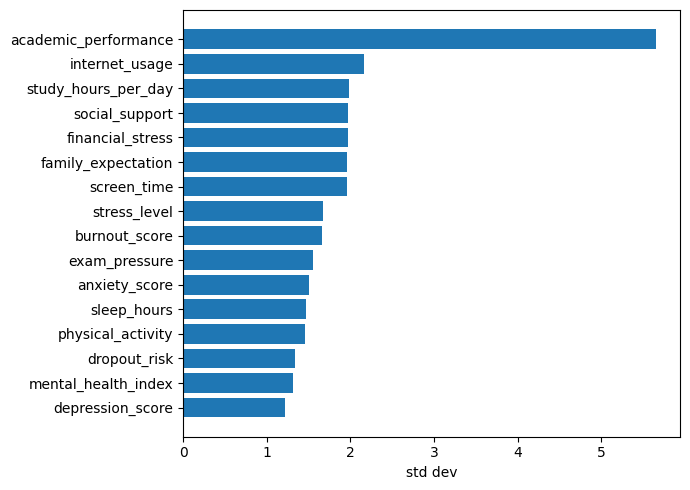

In [ ]:
import matplotlib.pyplot as plt

std_devs :dict[str, float] = {feat: df_1m[feat].std() for feat in continuous_feats}
std_devs = dict(sorted(std_devs.items(), key=lambda x: x[1]))
plt.figure(figsize=(7,5))
plt.barh(list(std_devs.keys()), list(std_devs.values()))
plt.xlabel("std dev")
plt.tight_layout()
plt.show()

## Boxplots

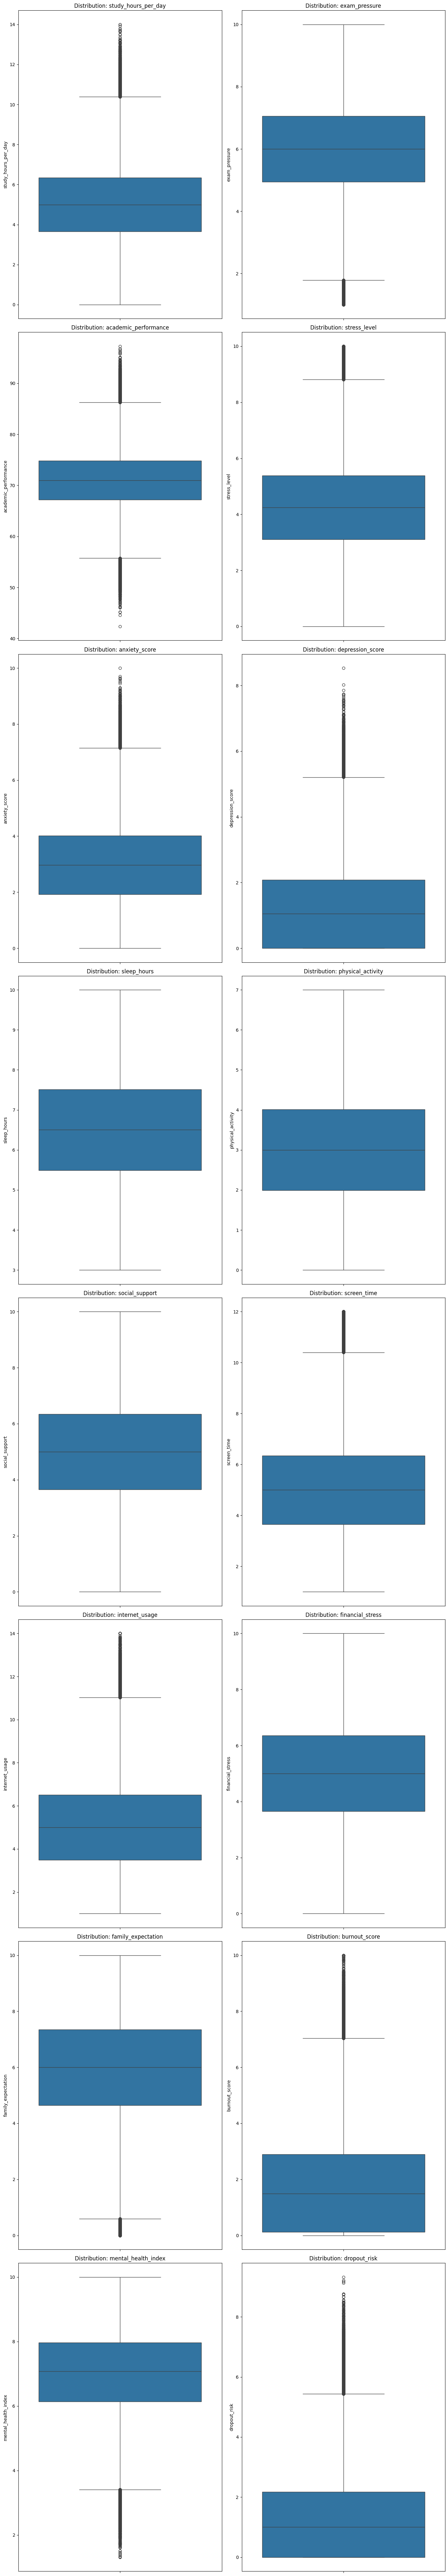

In [ ]:
import seaborn as sns

fig, ax = plt.subplots(nrows=8, ncols=2, figsize=(7*2, 10*8))
for i in range(len(continuous_feats)):
    plt.subplot(8,2, i+1)
    sns.boxplot(data=df_1m, y=continuous_feats[i])
    plt.title(f"Distribution: {continuous_feats[i]}")
plt.tight_layout()
plt.show()

## Histograms

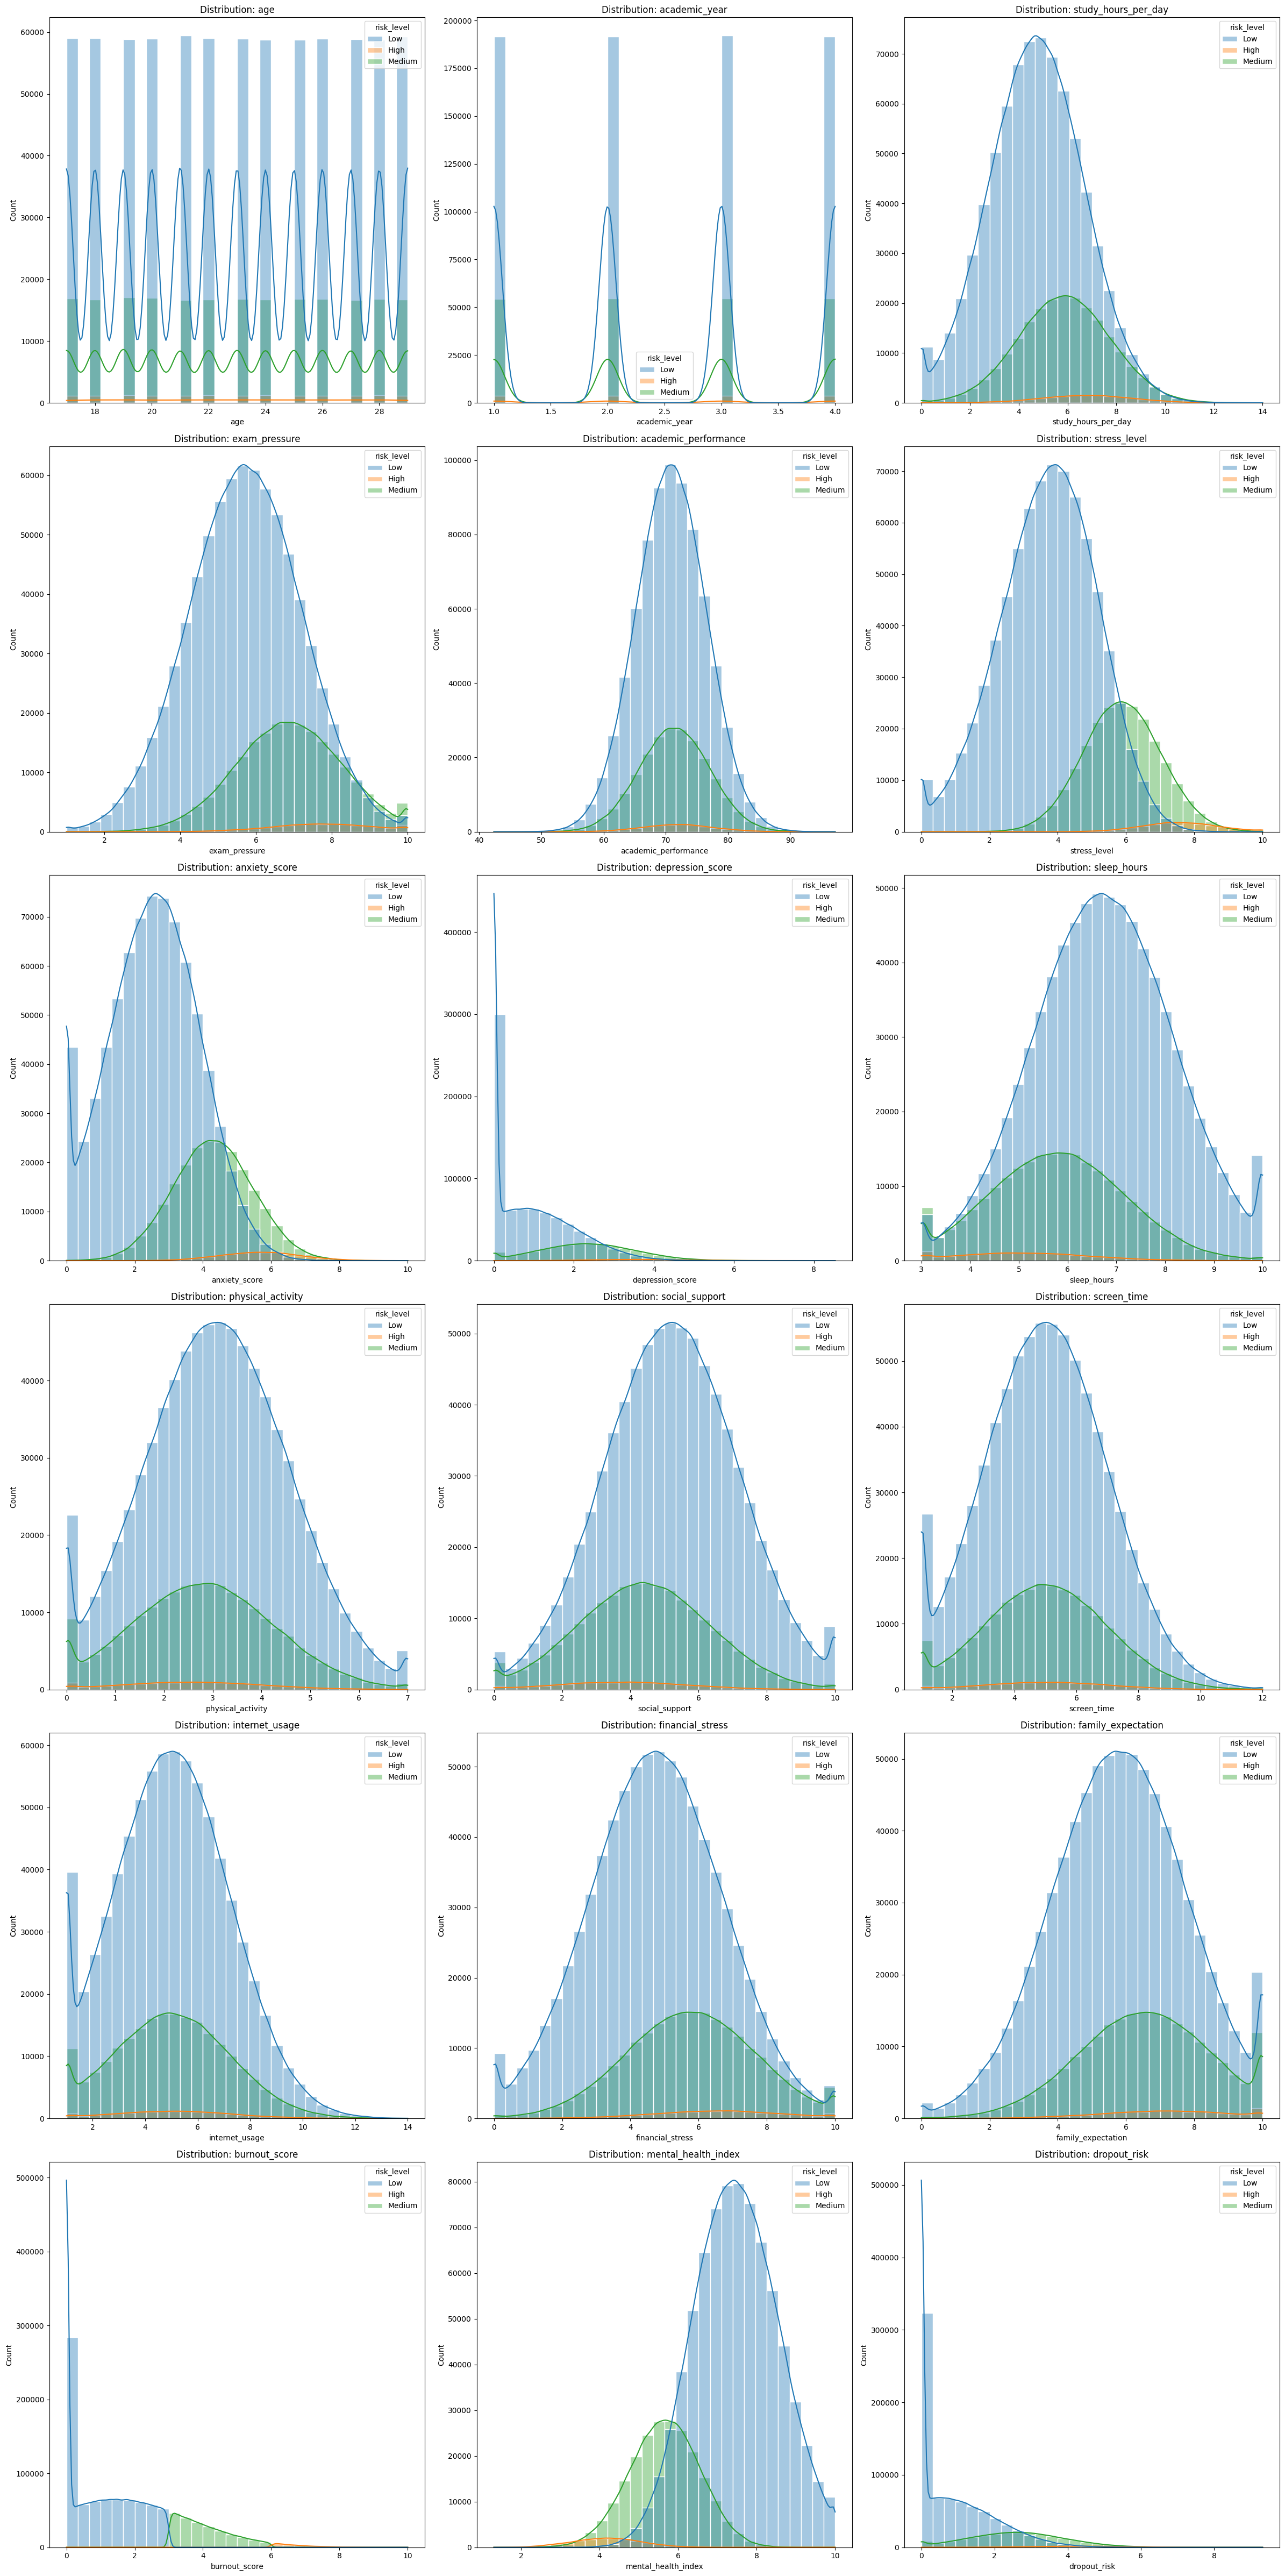

In [ ]:
fig, ax = plt.subplots(nrows=6, ncols=3, figsize=(8*3, 8*6))
for i in range(len(num_feats)):
    plt.subplot(6,3, i+1)
    sns.histplot(
        data=df_1m,
        x=num_feats[i],
        hue="risk_level",
        kde=True,
        bins=30,
        alpha= .4,
        edgecolor=(1,1,1)
    )
    plt.title(f"Distribution: {num_feats[i]}")
plt.tight_layout()
plt.show()

## Covariance matrix

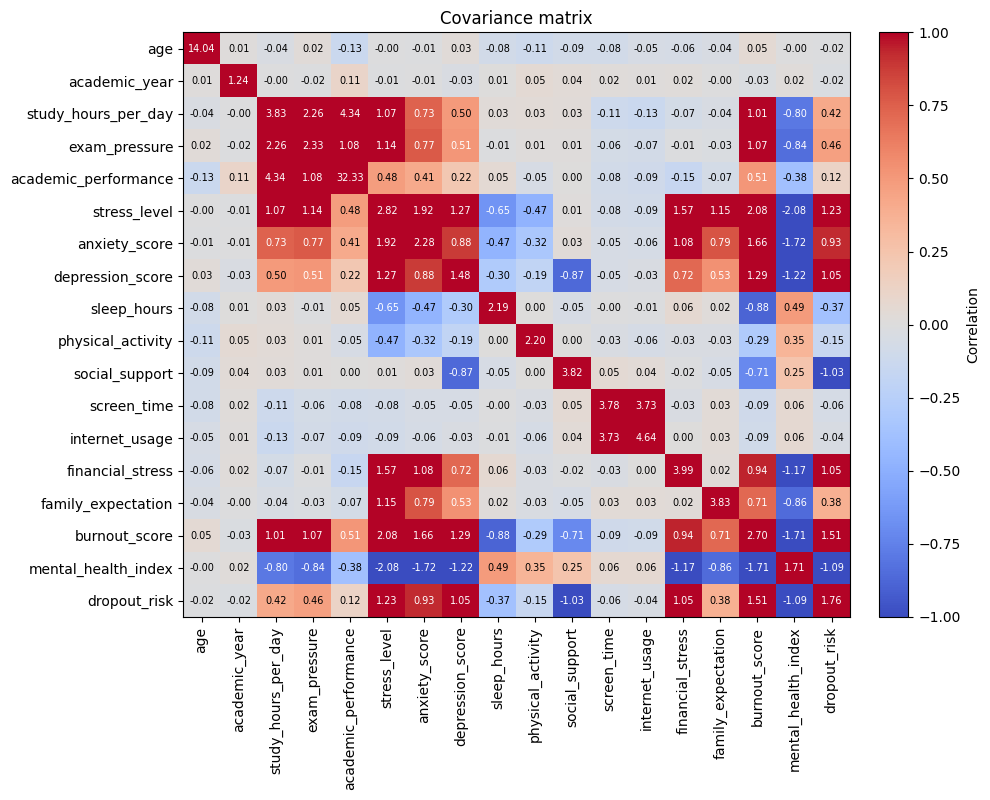

In [ ]:
import numpy as np

# sample to make the computation feasible
SAMPLE_SIZE = 10_000
idx = np.random.default_rng(1234).choice(len(df_1m), size=SAMPLE_SIZE, replace=False)
num_df_reduced = df_1m[num_feats].iloc[idx].copy()

cov_mat = num_df_reduced.cov()

plt.figure(figsize=(max(10, 0.45 * len(num_feats)), max(8, 0.45 * len(num_feats))))
im0 = plt.imshow(
    cov_mat.values, 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    aspect="auto"
    )
plt.colorbar(im0, fraction=0.046, pad=0.04, label="Correlation")
plt.xticks(range(len(num_feats)), num_feats, rotation=90)
plt.yticks(range(len(num_feats)), num_feats)

for i in range(cov_mat.shape[0]):
    for j in range(cov_mat.shape[1]):
        value = cov_mat.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center", 
                color="black" if abs(value) < 0.5 else "white", fontsize=7)
plt.title("Covariance matrix")
plt.tight_layout()
plt.show()

## Correlation matrix

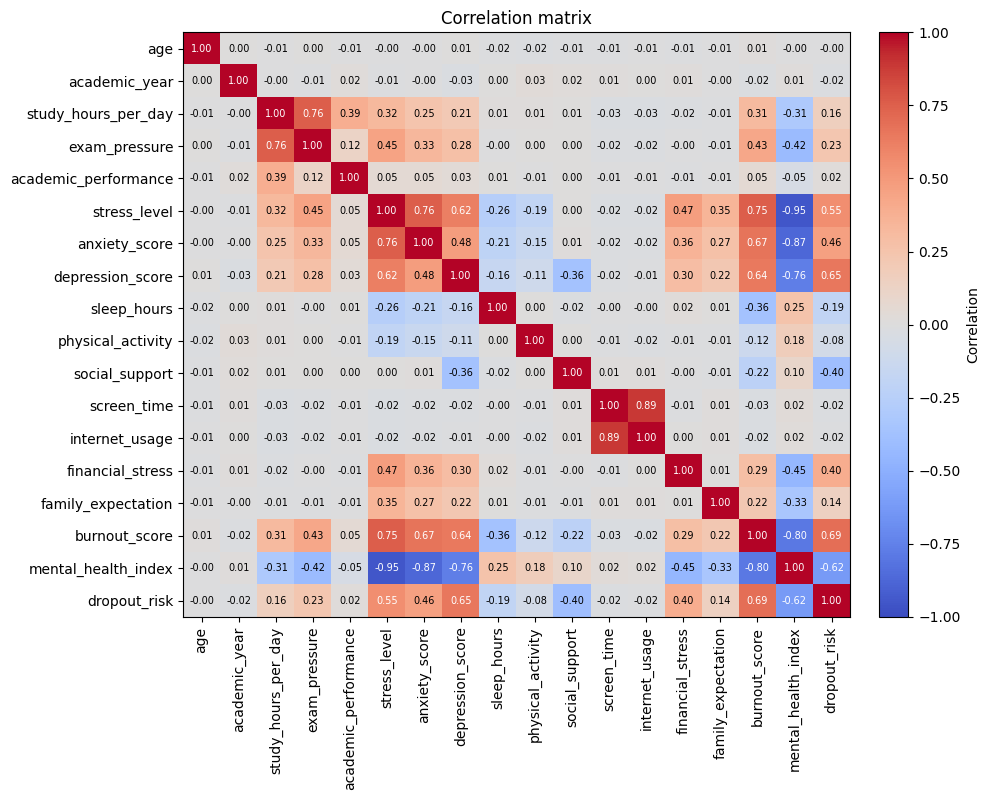

In [ ]:
corr_mat = num_df_reduced.corr()

plt.figure(figsize=(max(10, 0.45 * len(num_feats)), max(8, 0.45 * len(num_feats))))
im0 = plt.imshow(
    corr_mat.values, 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    aspect="auto"
    )
plt.colorbar(im0, fraction=0.046, pad=0.04, label="Correlation")
plt.xticks(range(len(num_feats)), num_feats, rotation=90)
plt.yticks(range(len(num_feats)), num_feats)

for i in range(corr_mat.shape[0]):
    for j in range(corr_mat.shape[1]):
        value = corr_mat.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center", 
                color="black" if abs(value) < 0.5 else "white", fontsize=7)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

## Scatter plots

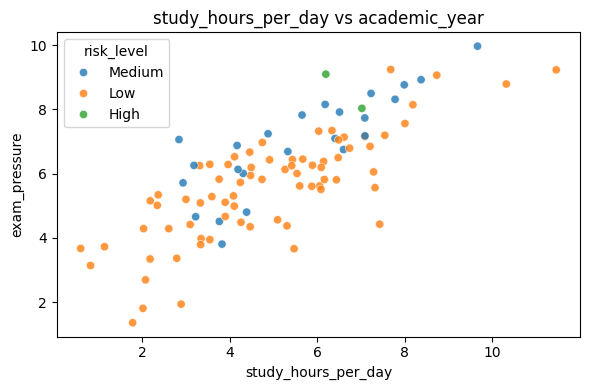

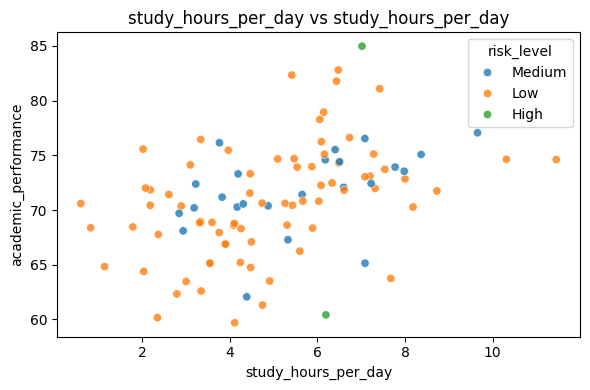

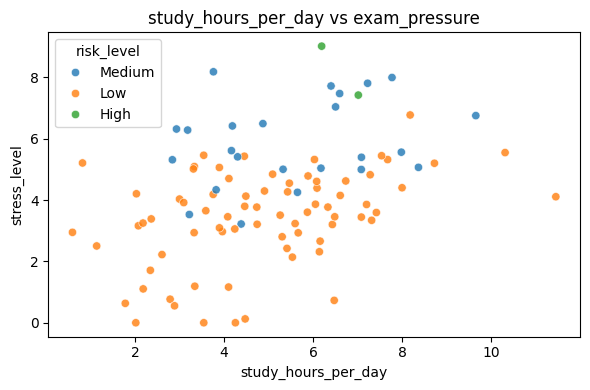

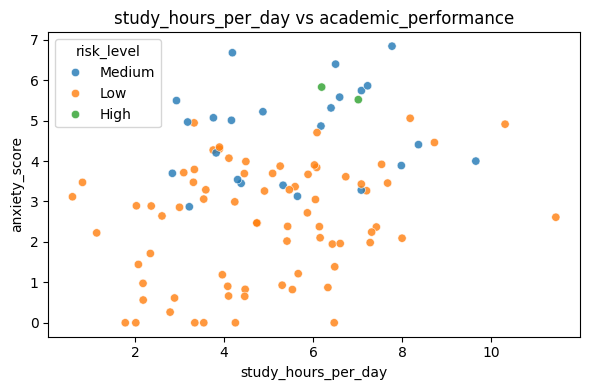

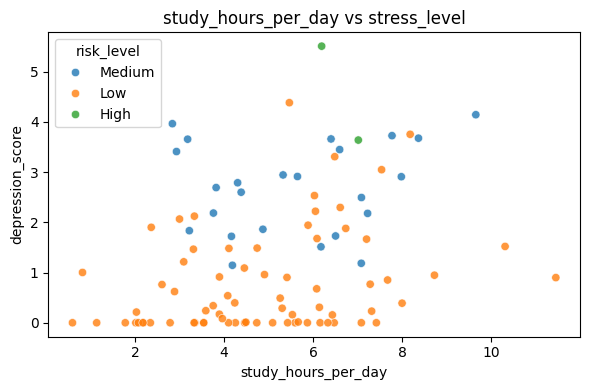

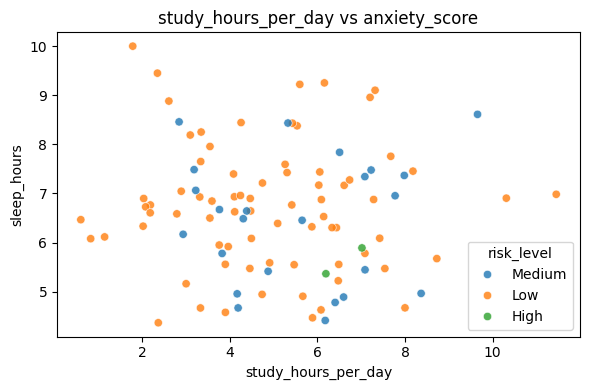

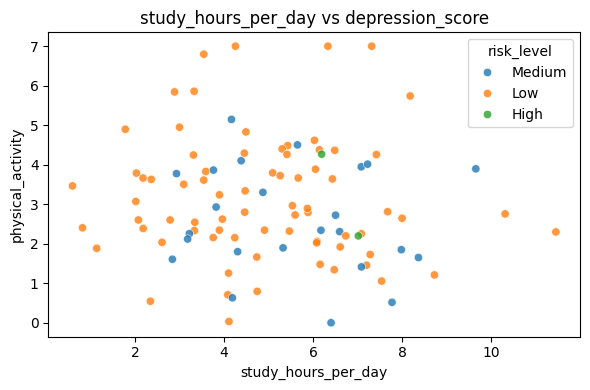

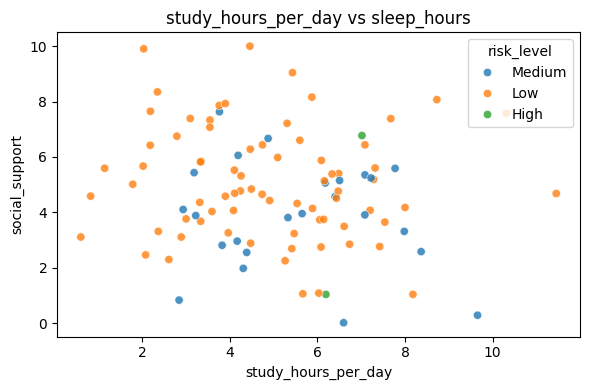

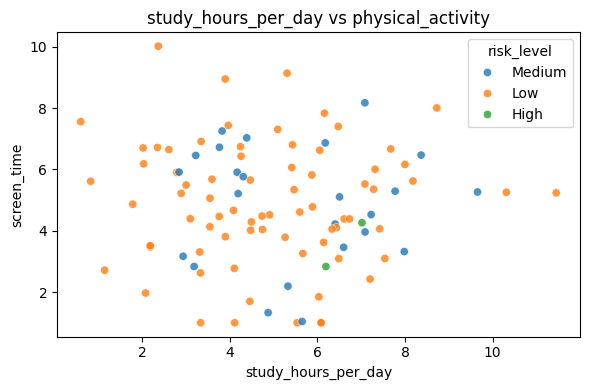

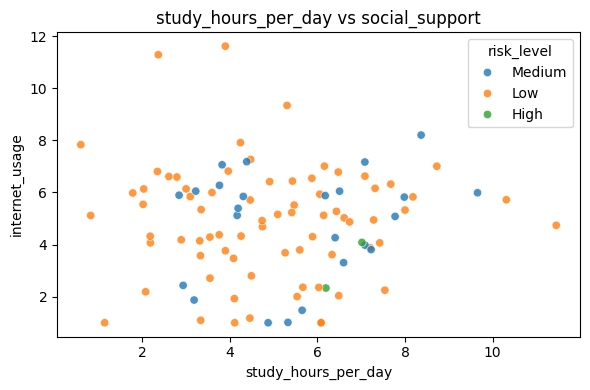

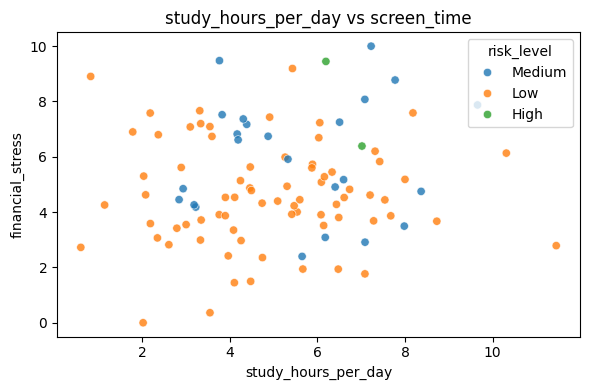

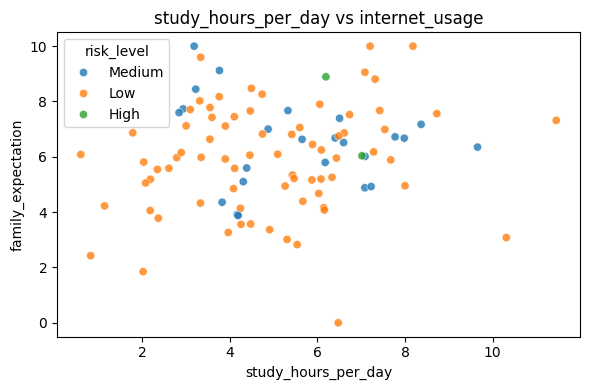

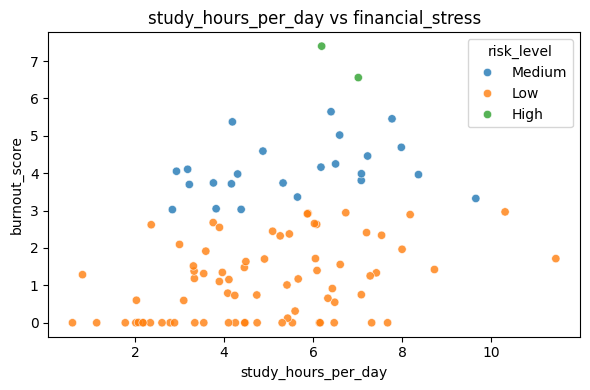

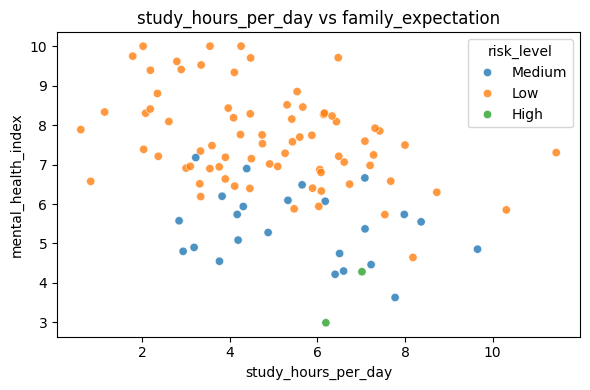

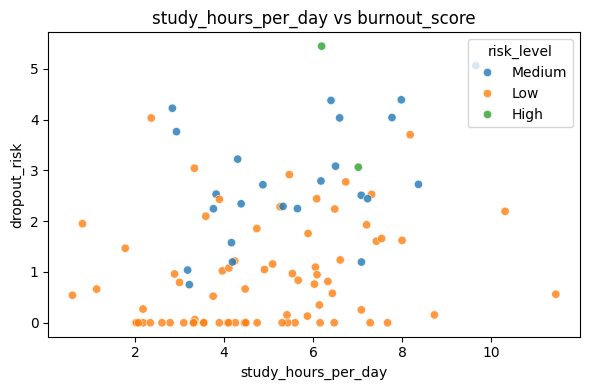

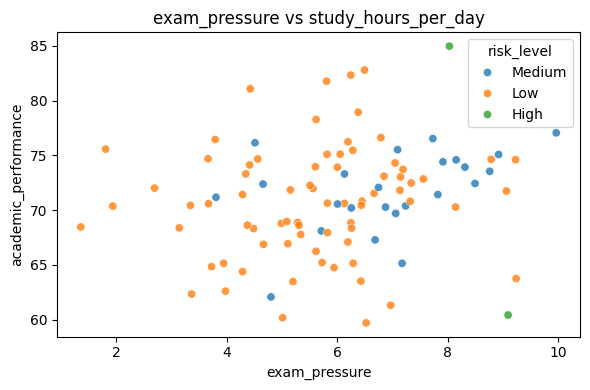

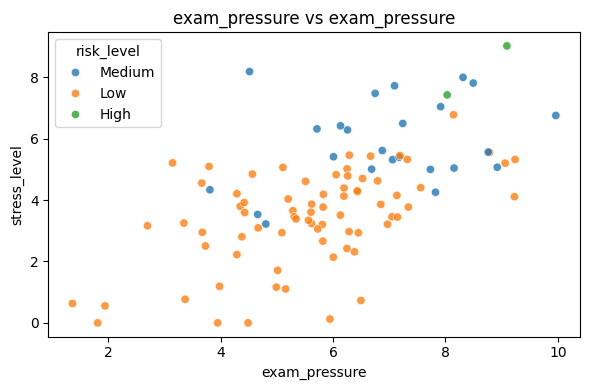

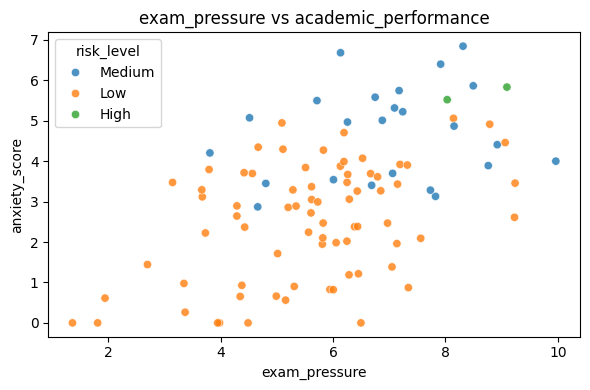

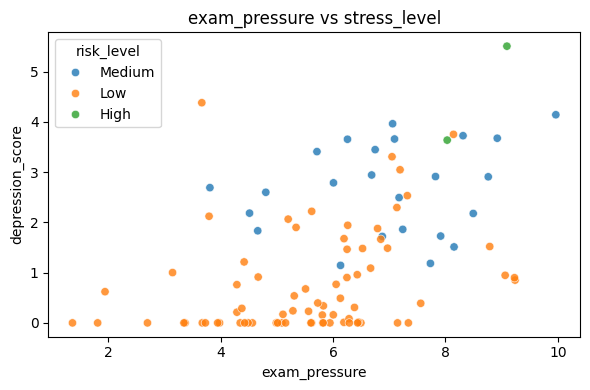

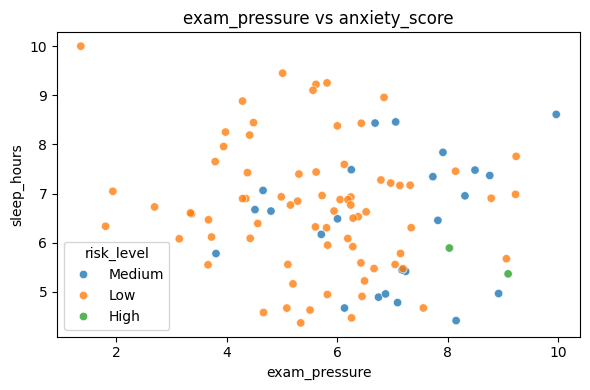

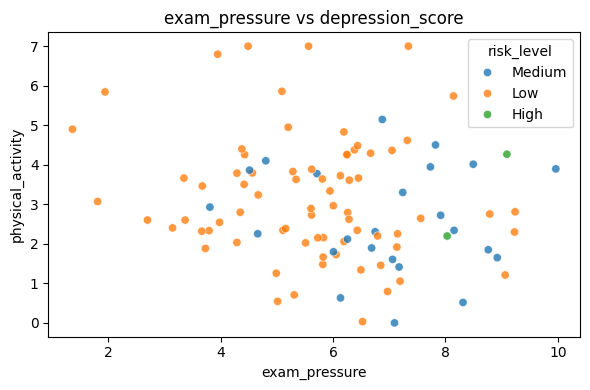

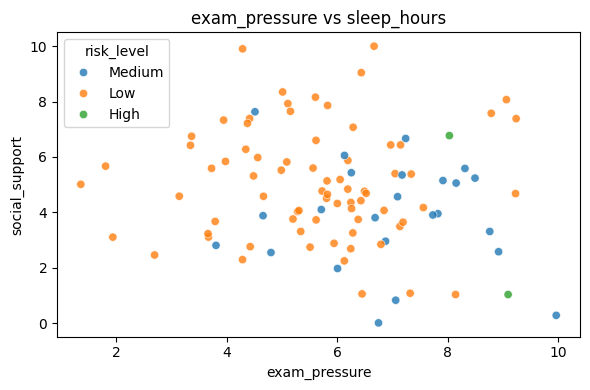

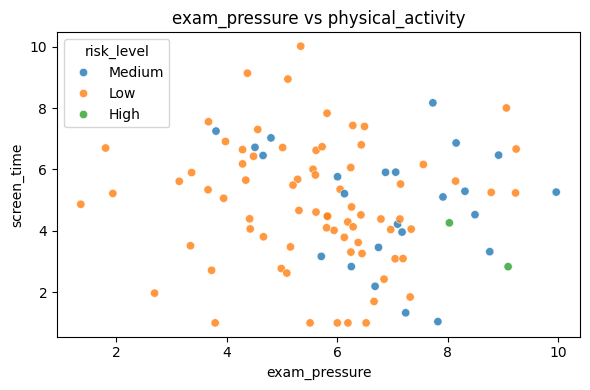

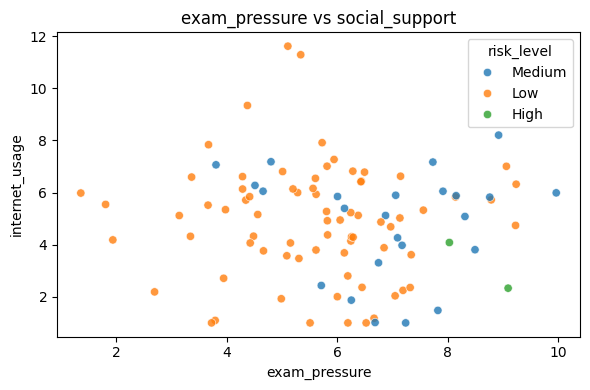

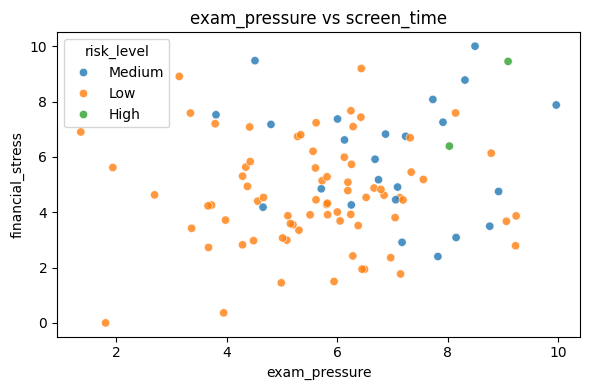

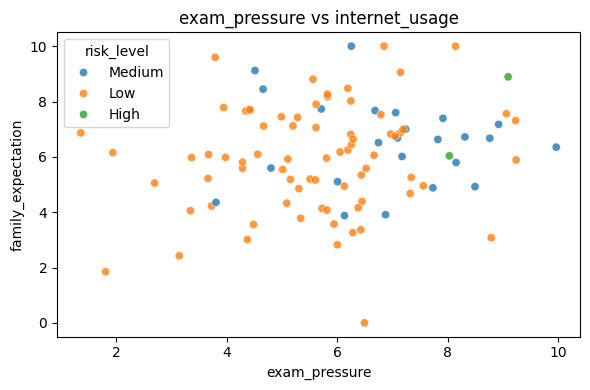

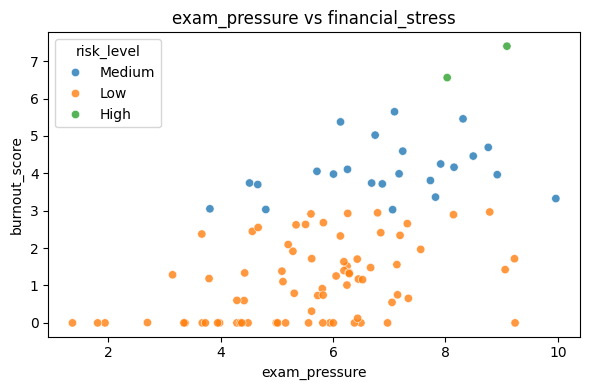

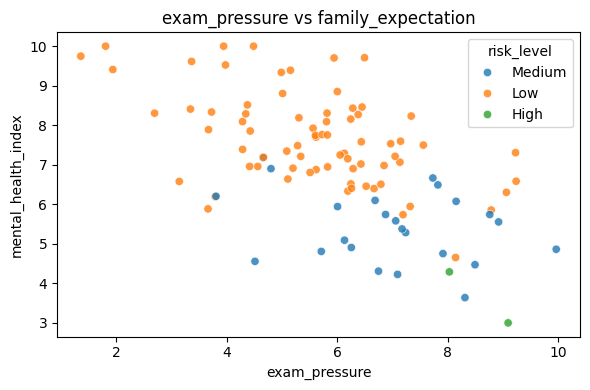

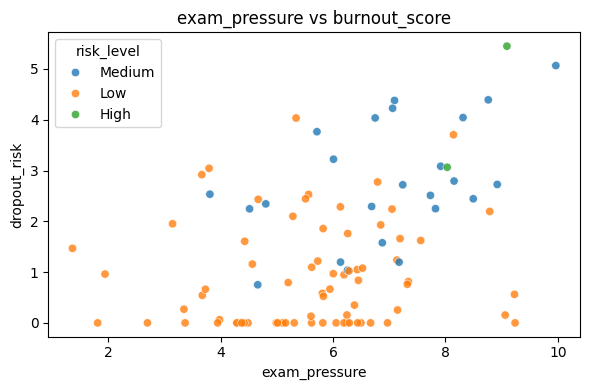

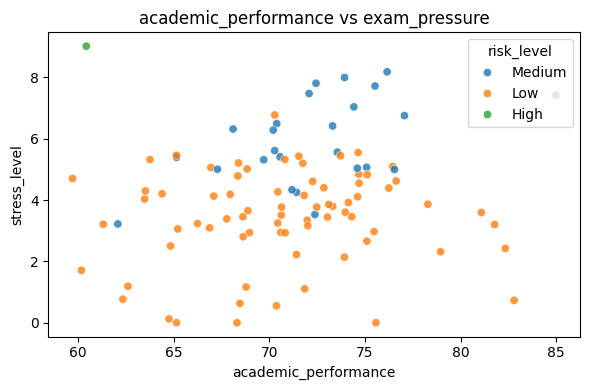

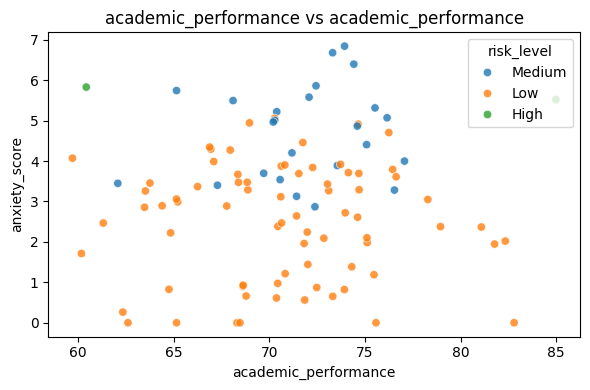

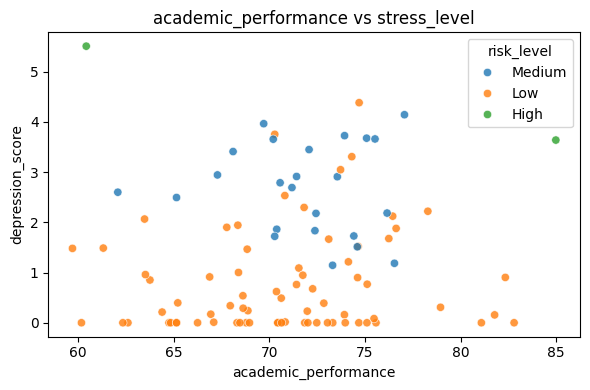

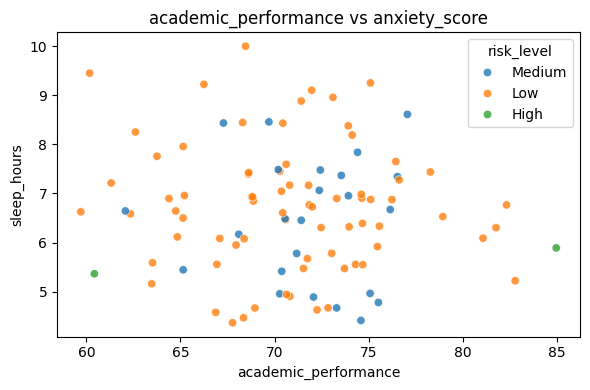

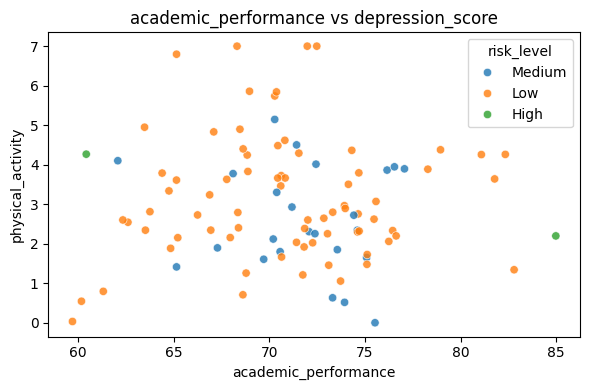

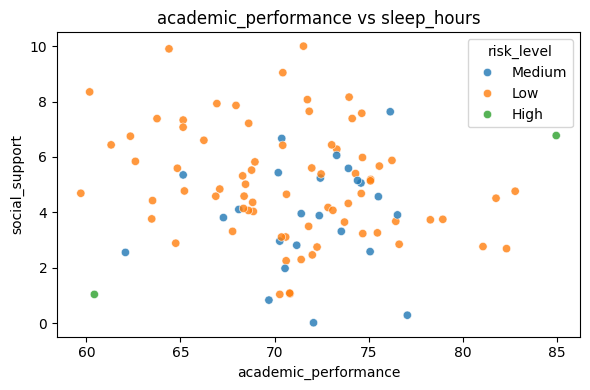

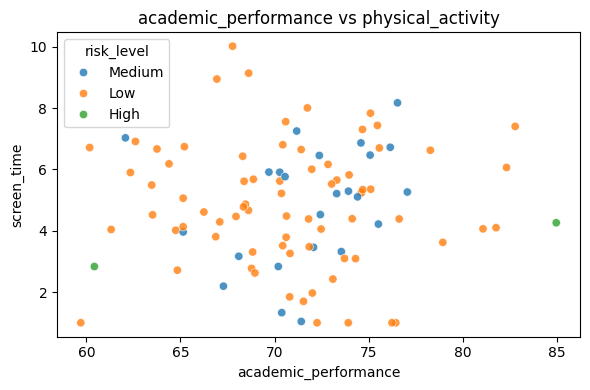

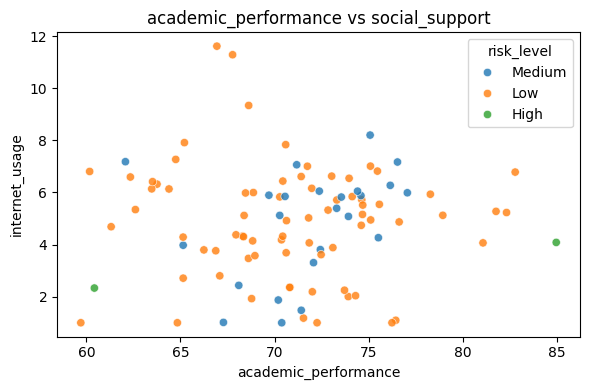

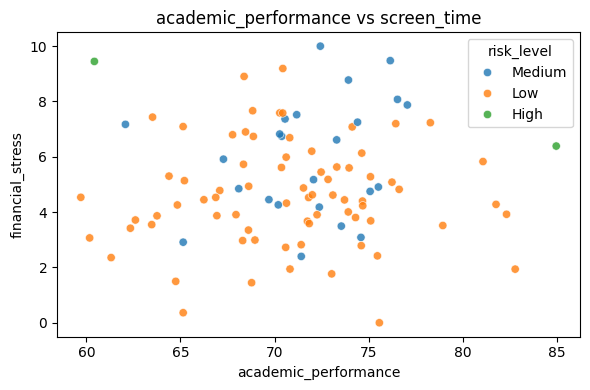

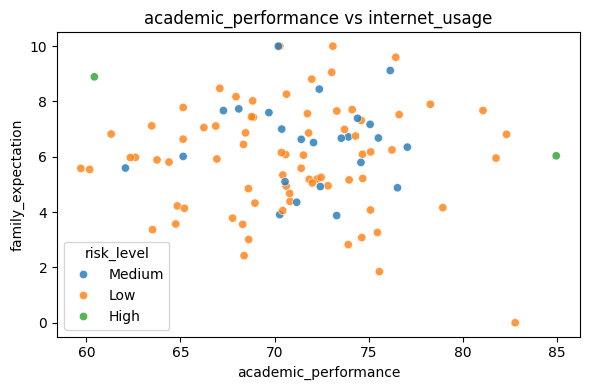

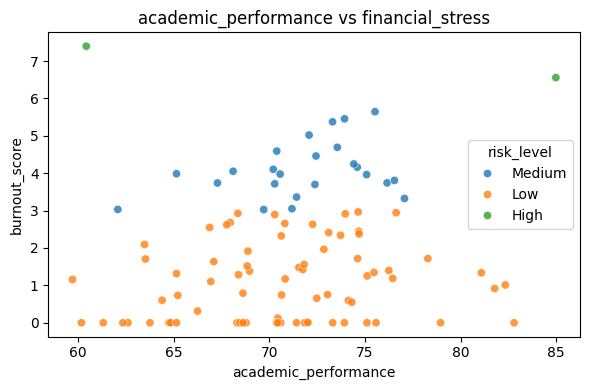

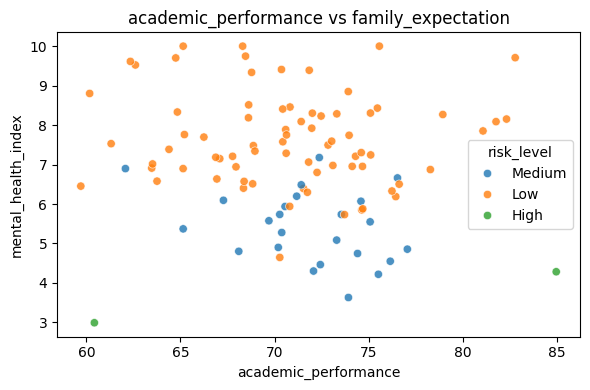

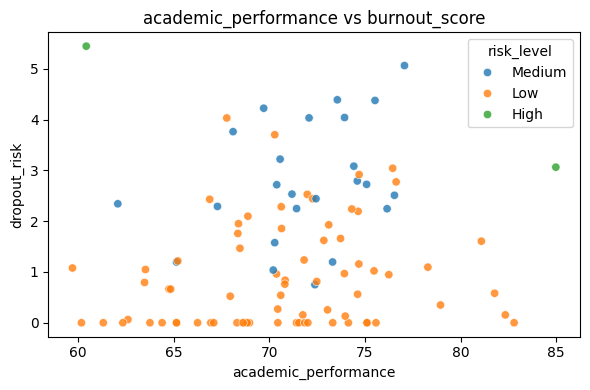

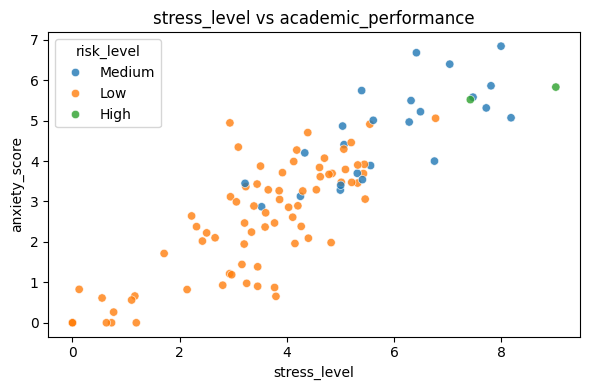

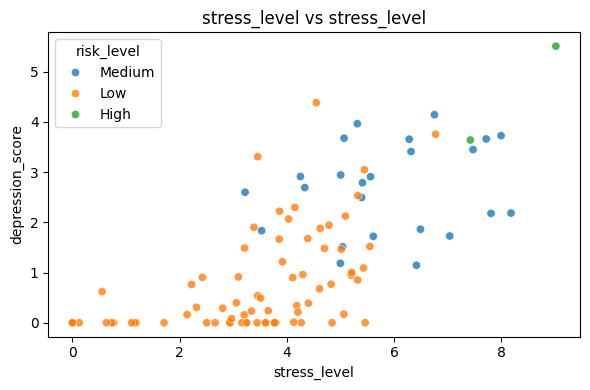

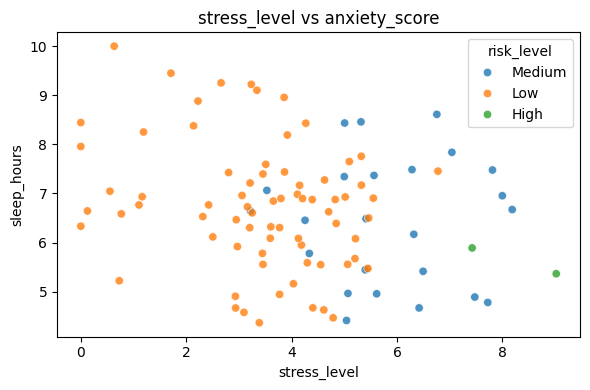

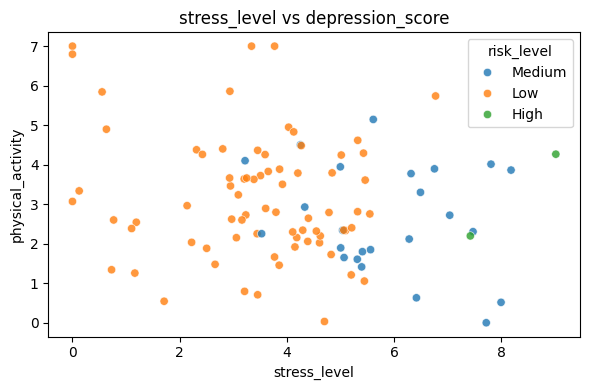

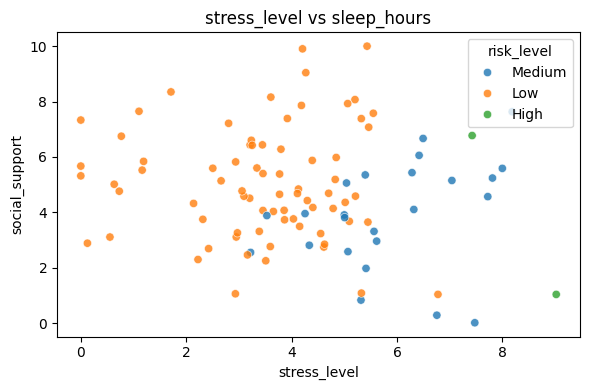

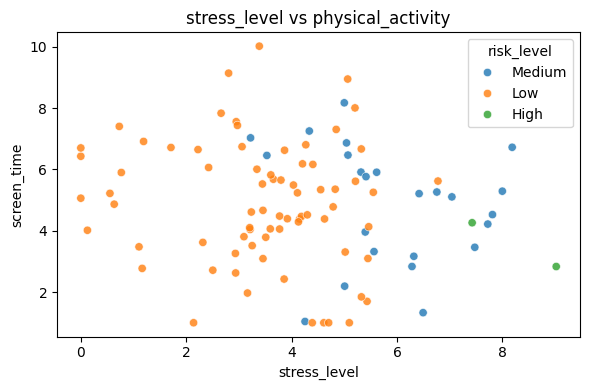

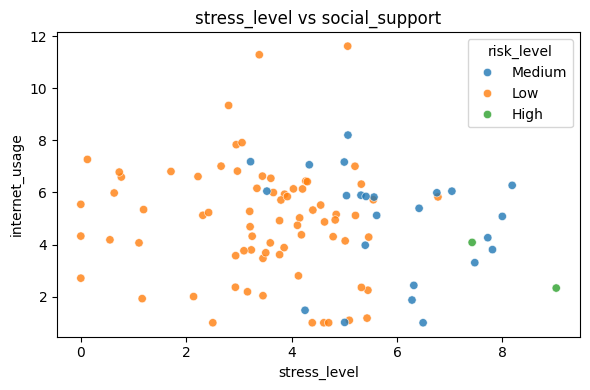

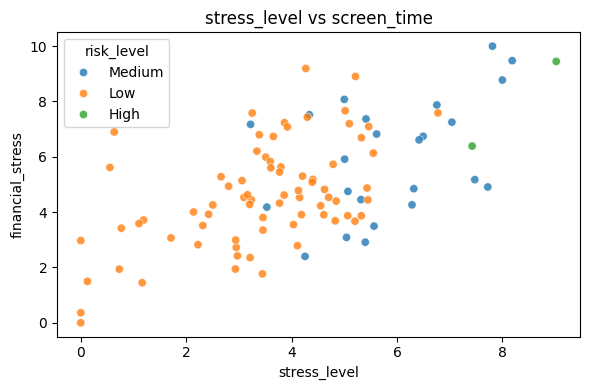

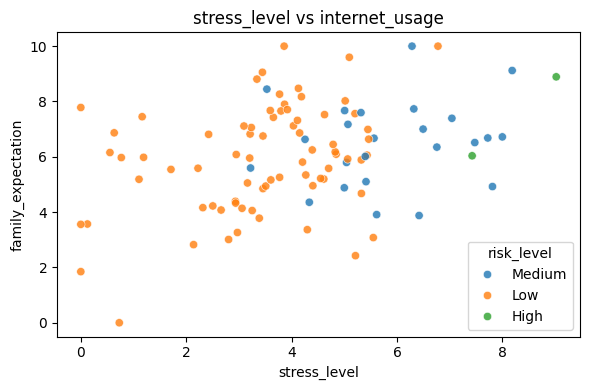

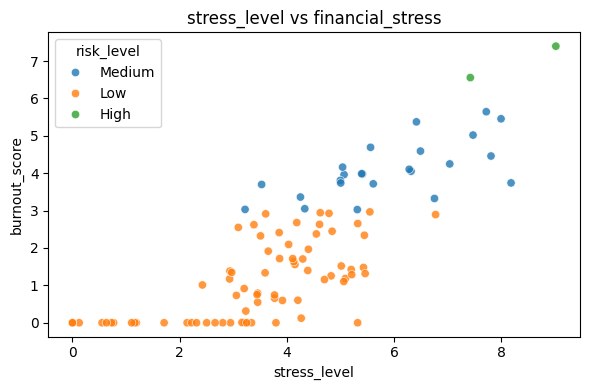

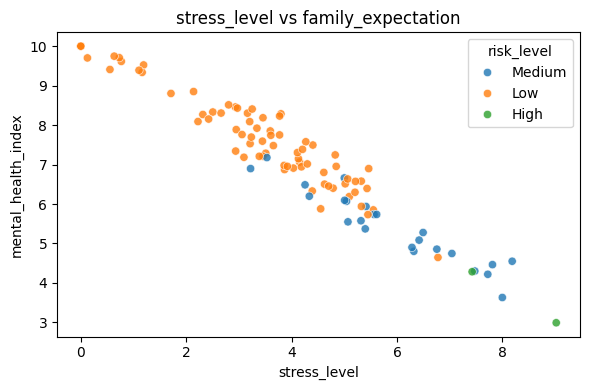

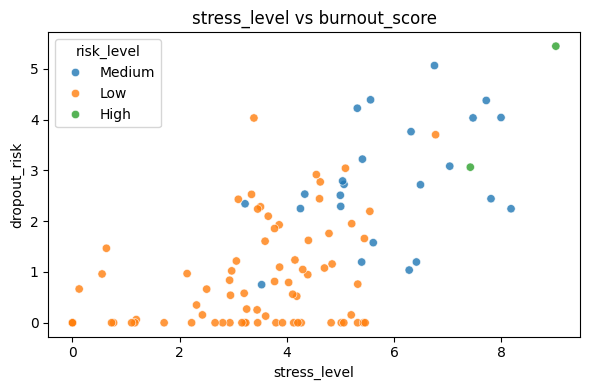

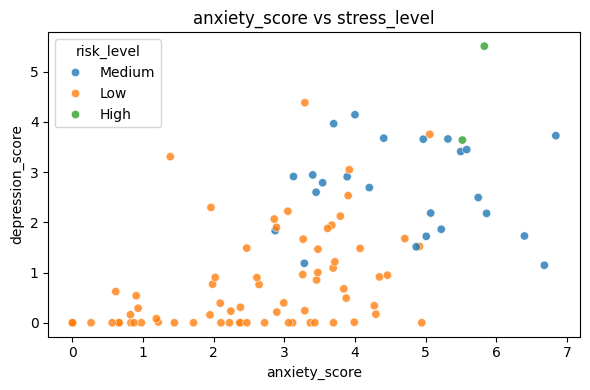

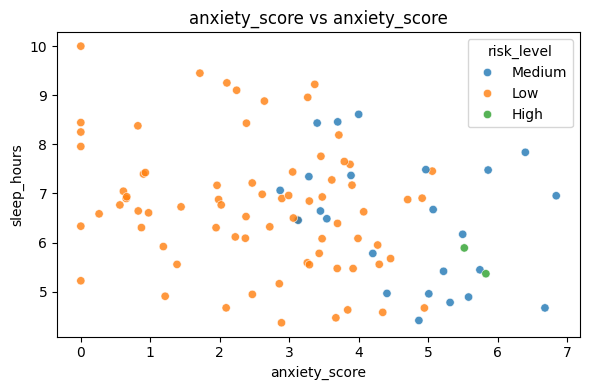

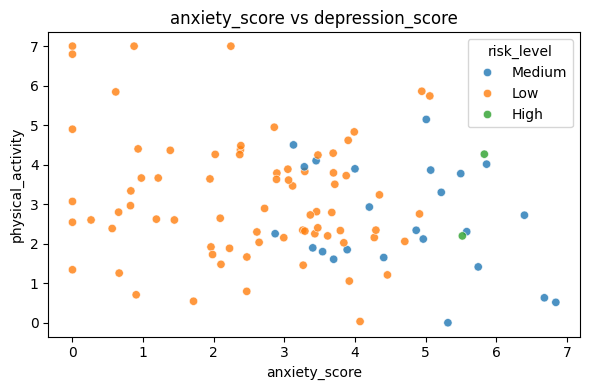

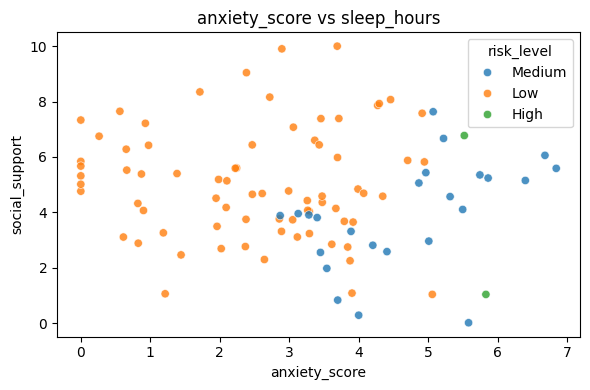

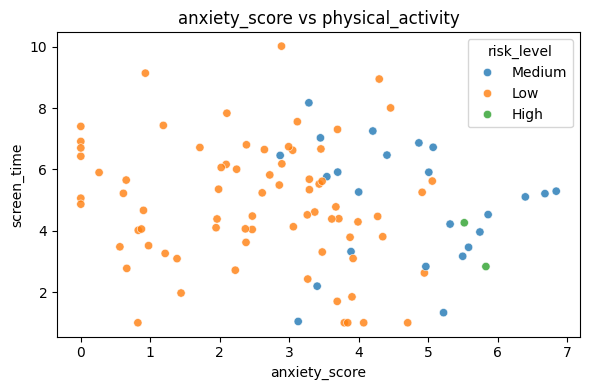

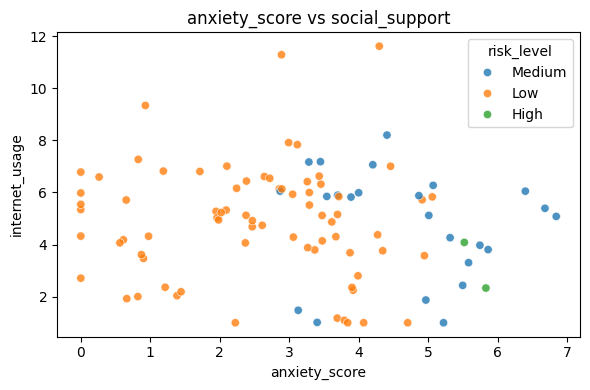

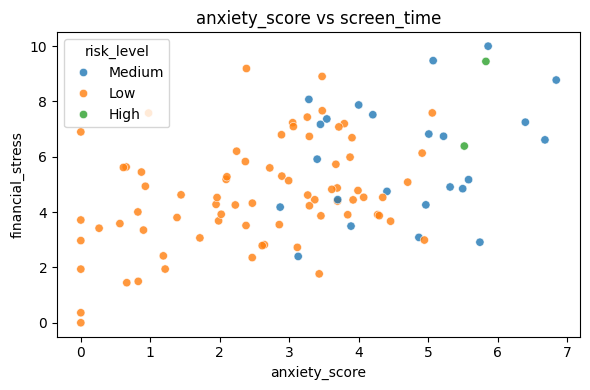

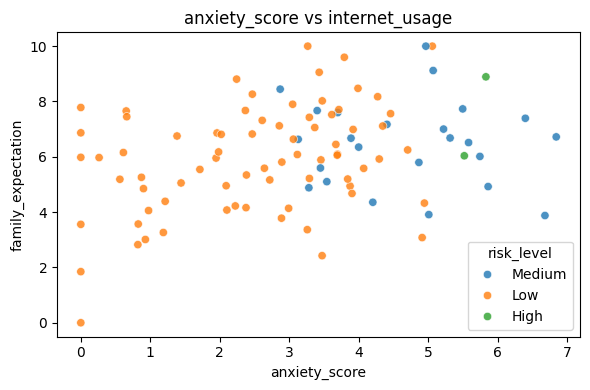

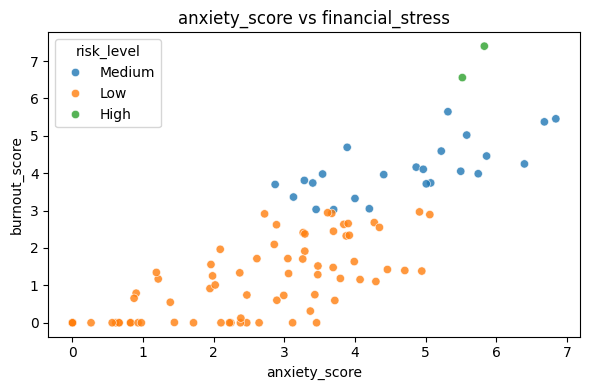

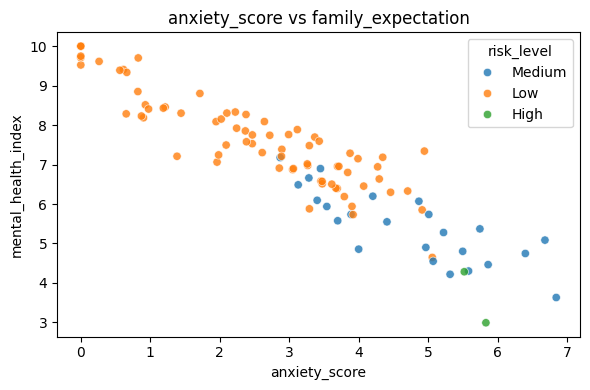

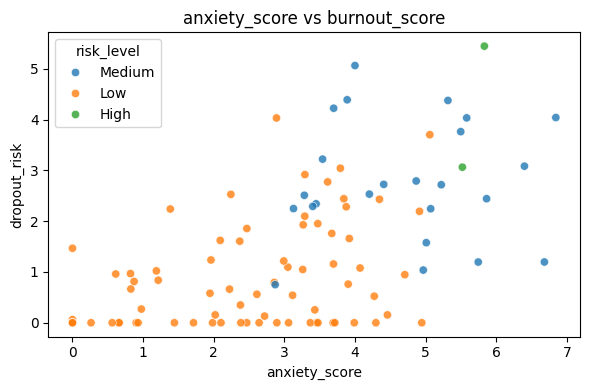

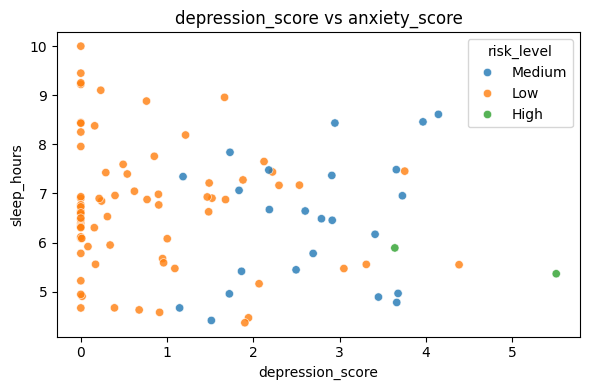

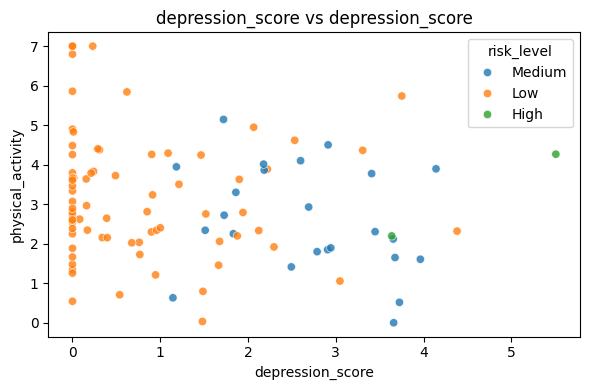

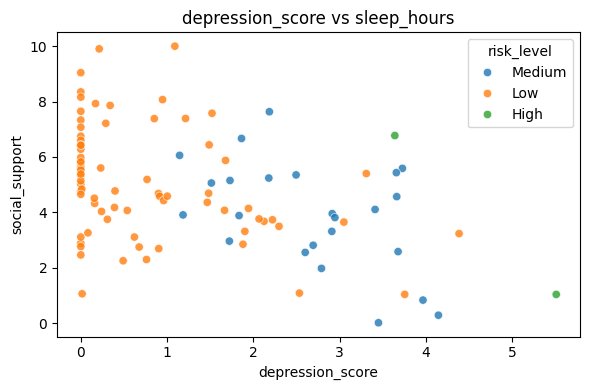

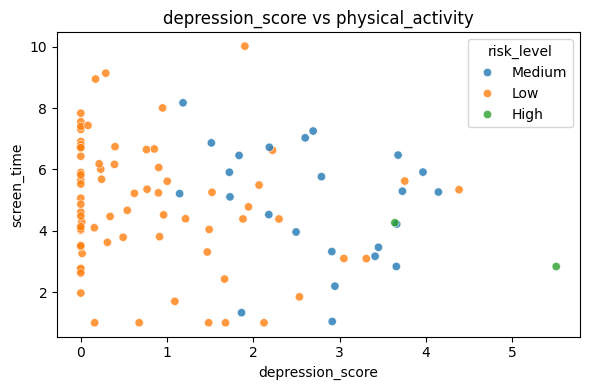

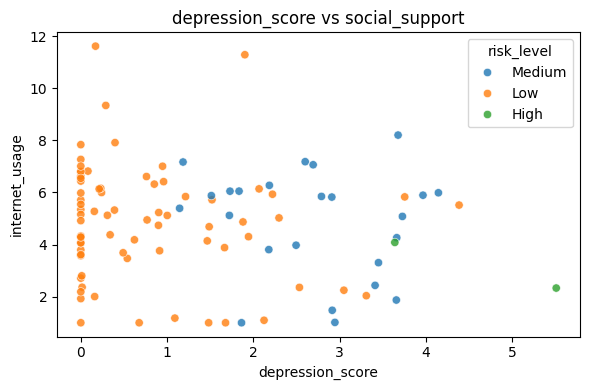

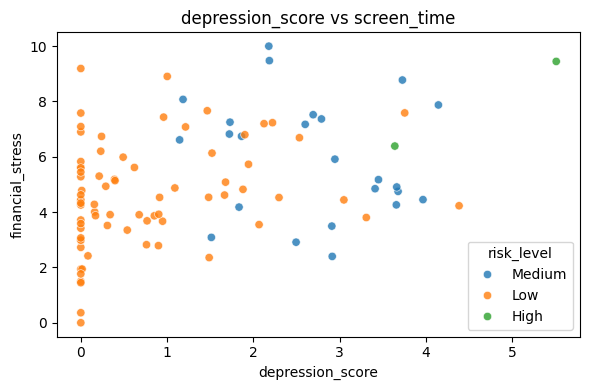

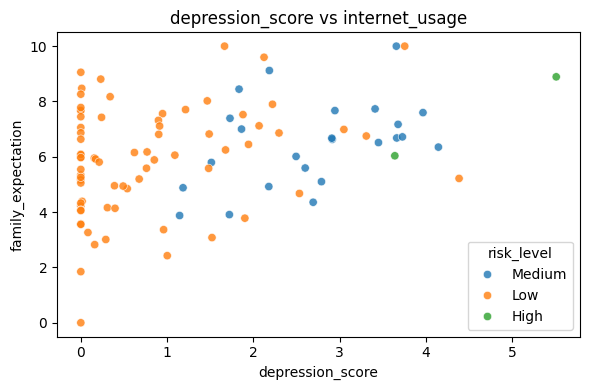

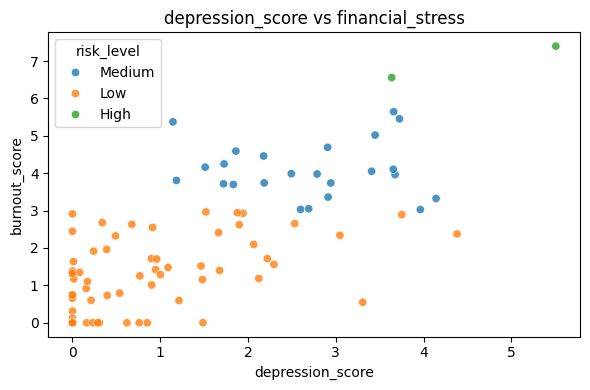

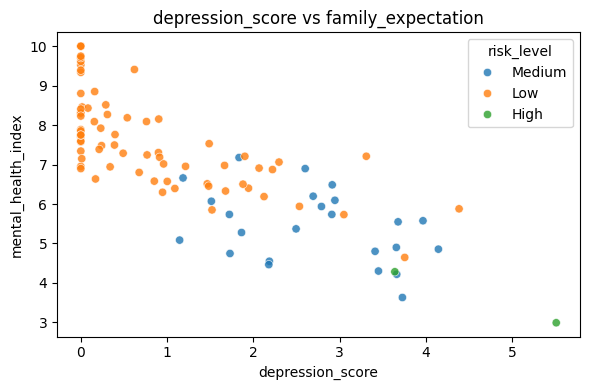

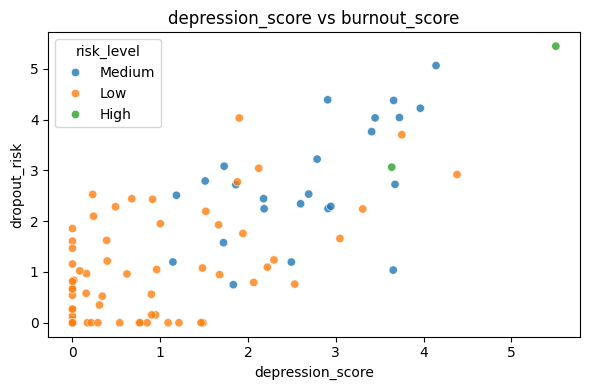

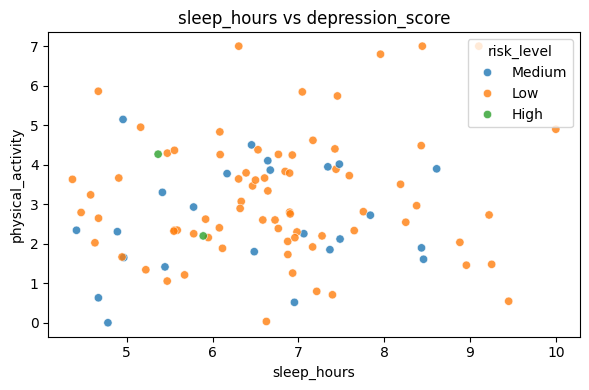

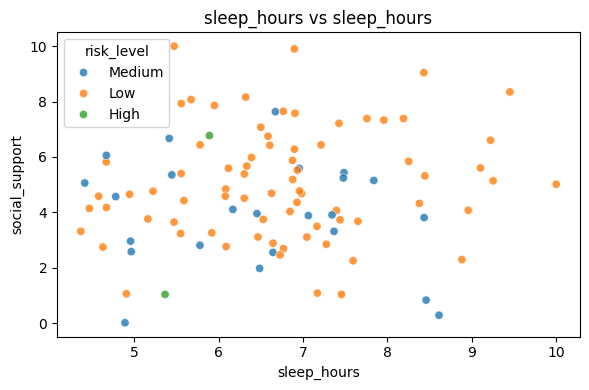

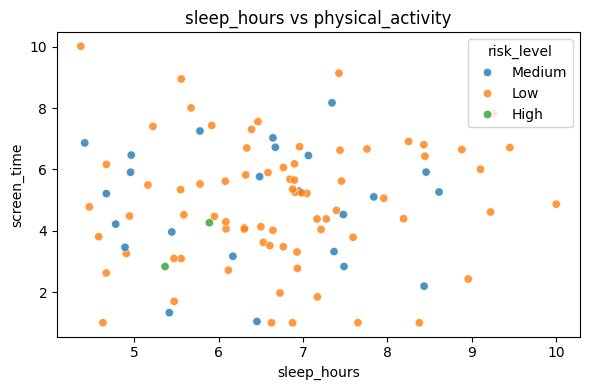

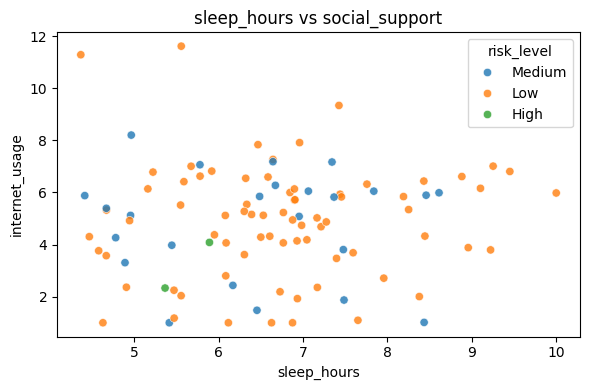

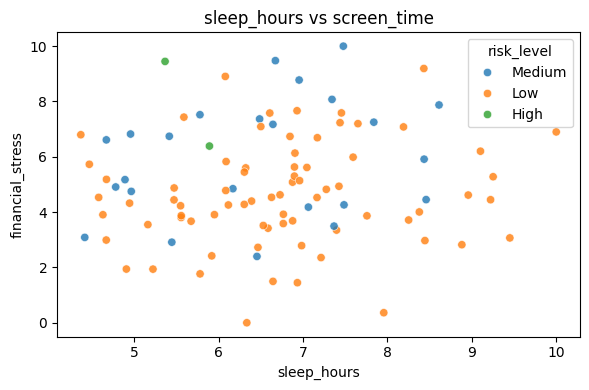

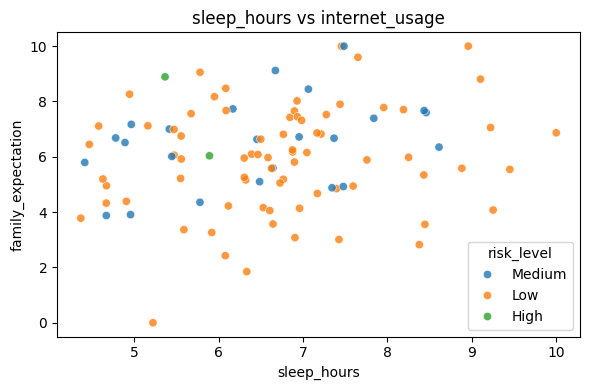

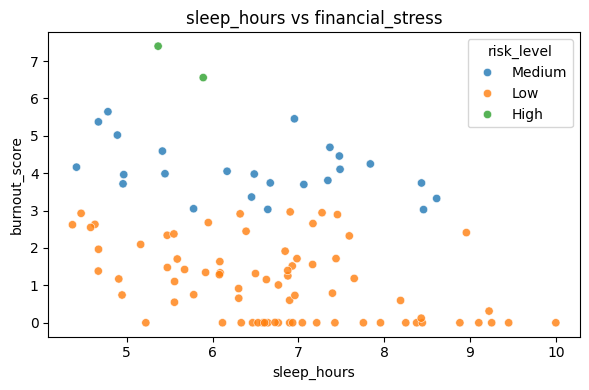

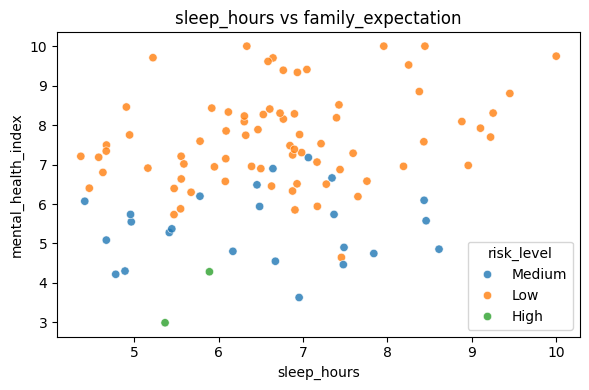

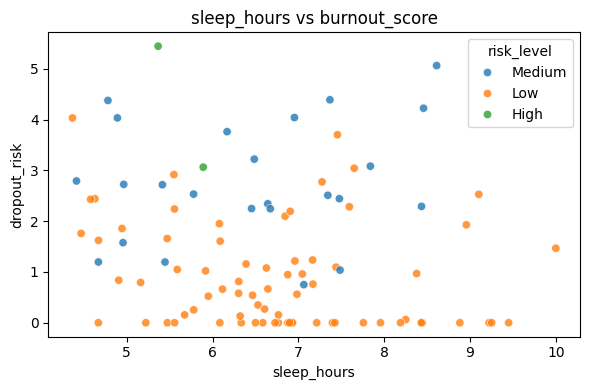

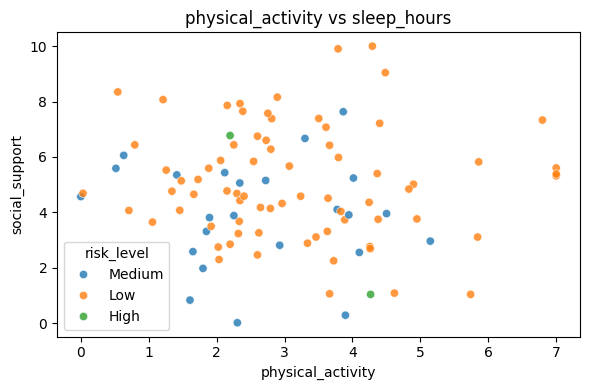

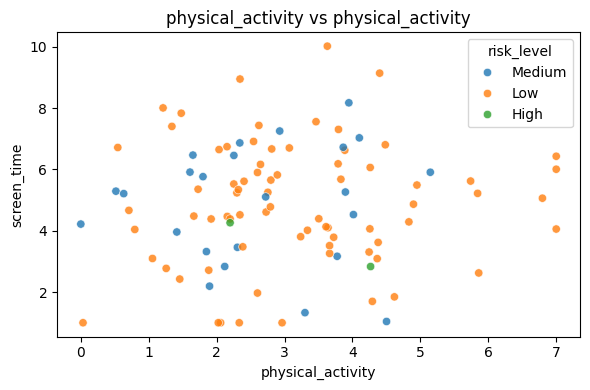

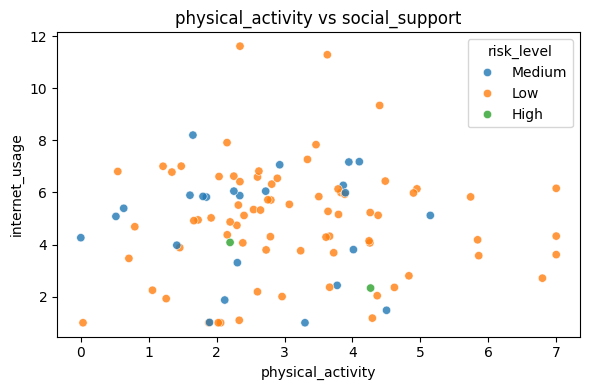

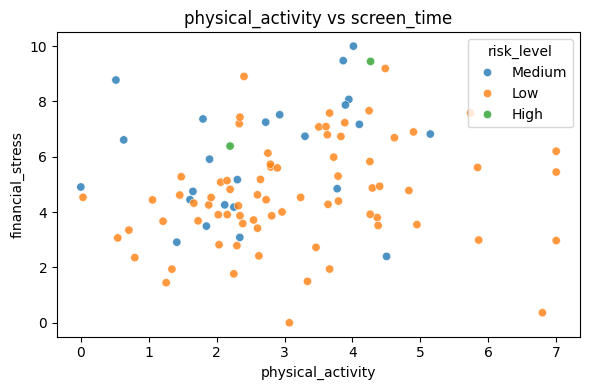

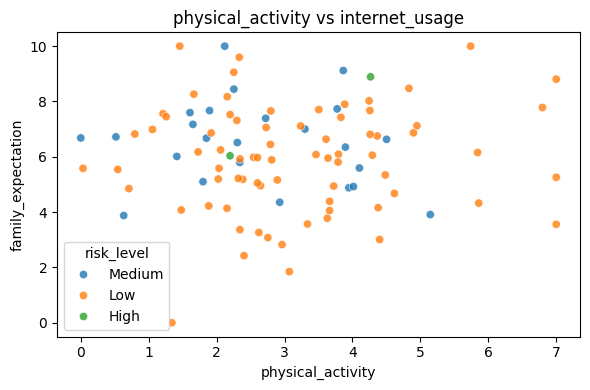

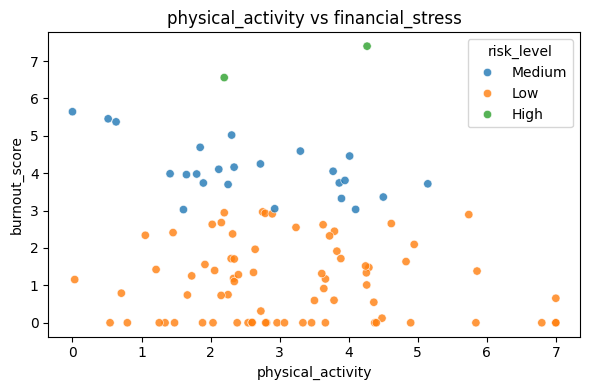

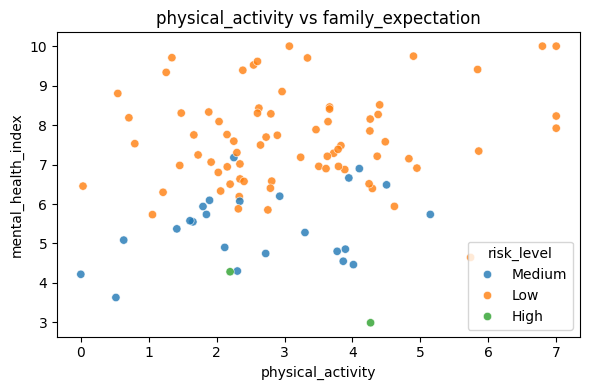

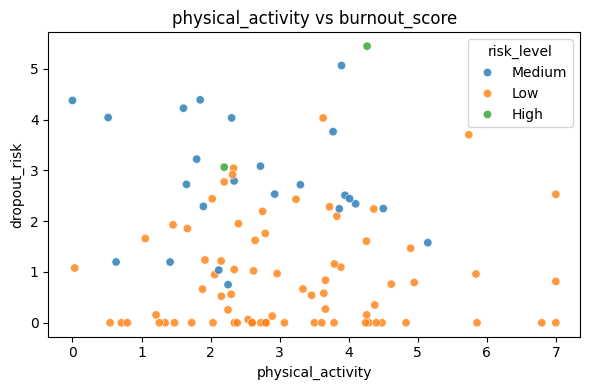

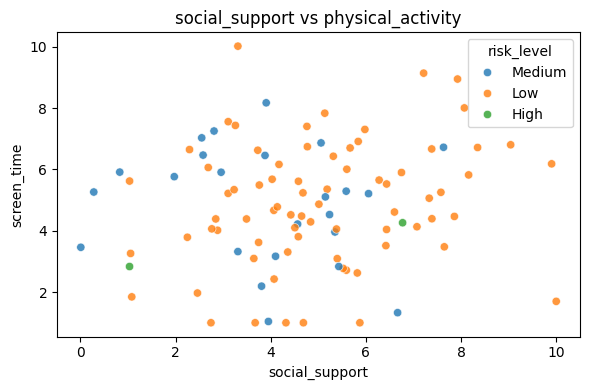

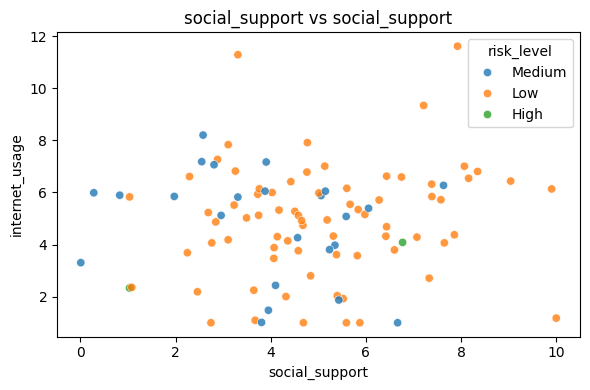

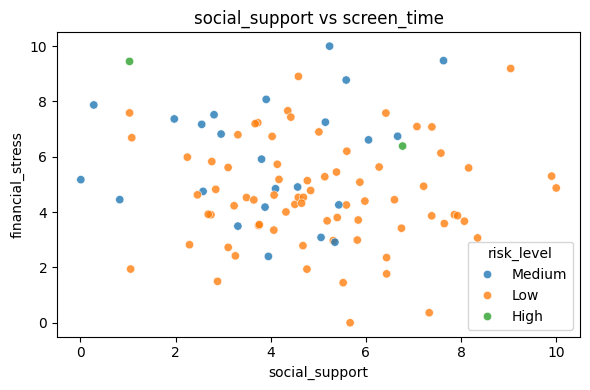

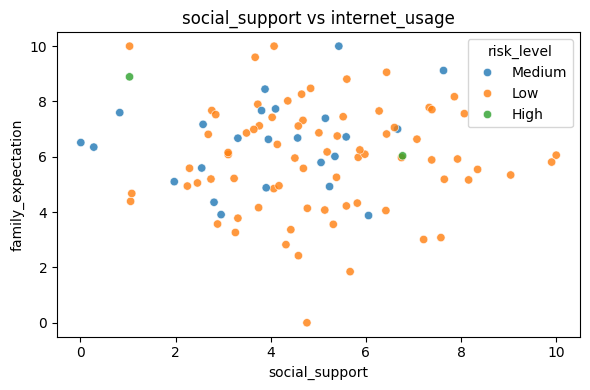

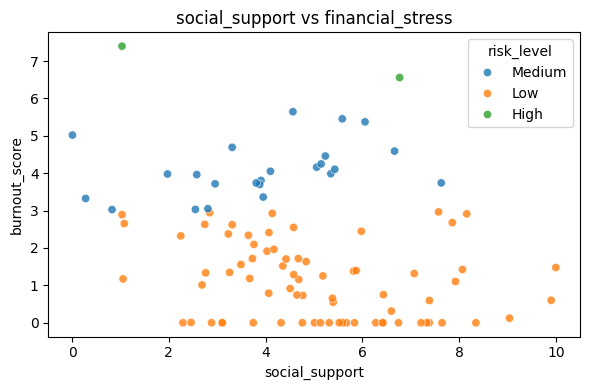

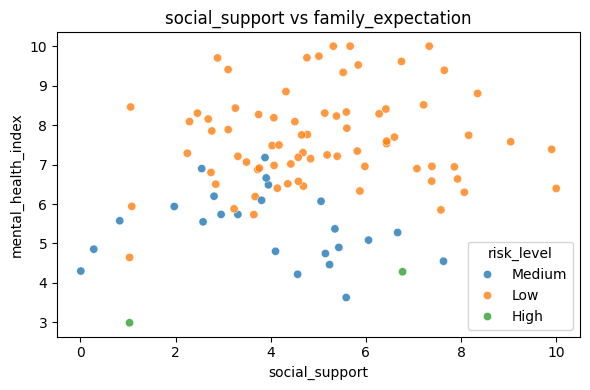

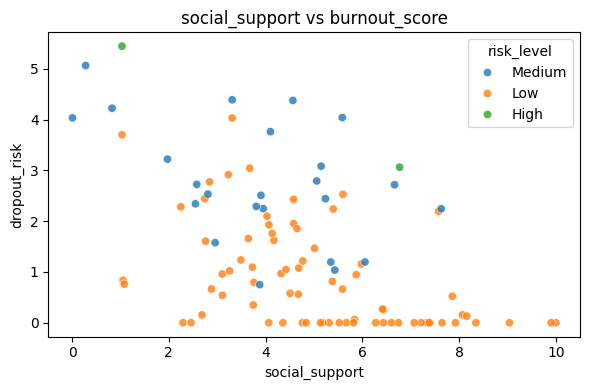

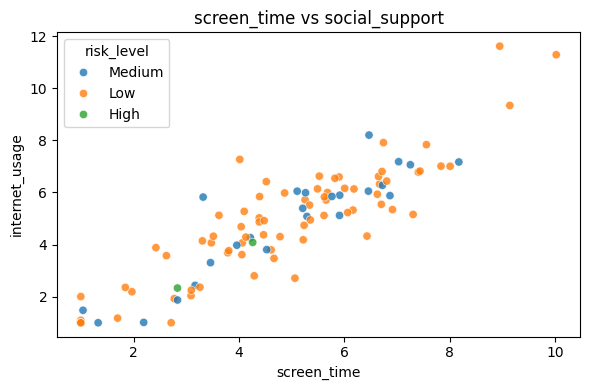

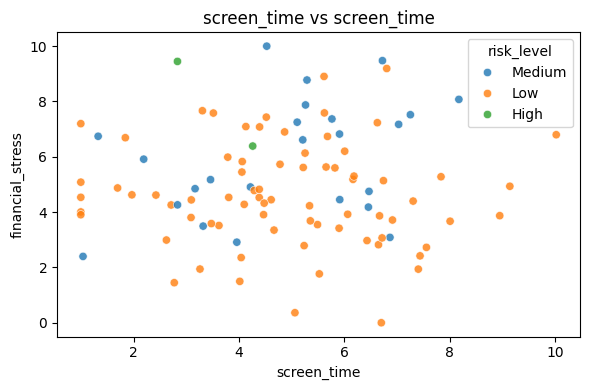

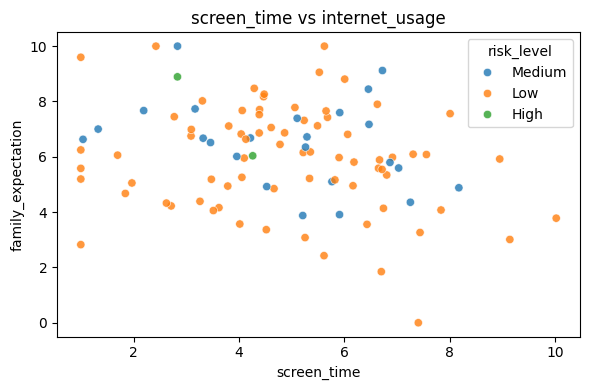

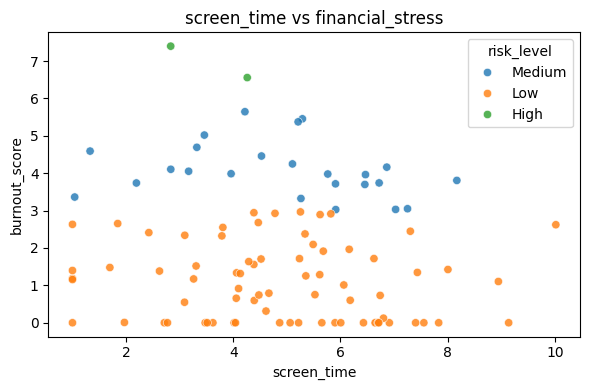

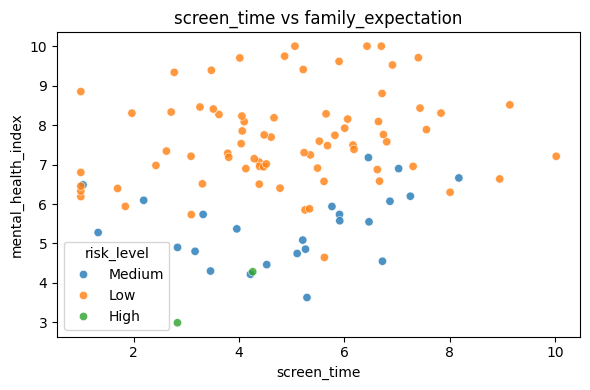

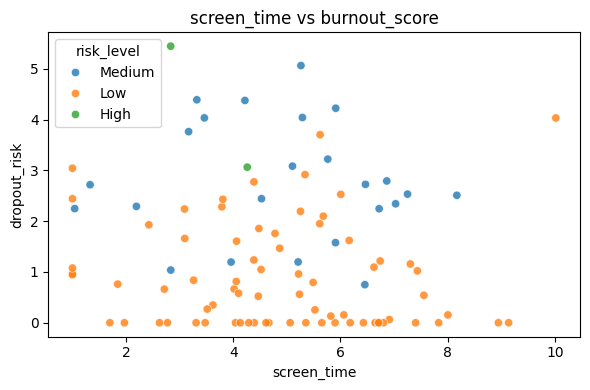

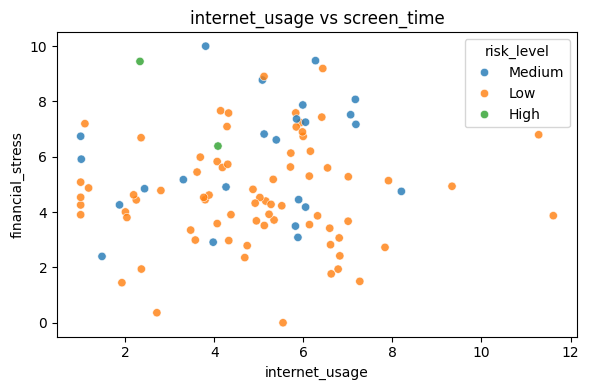

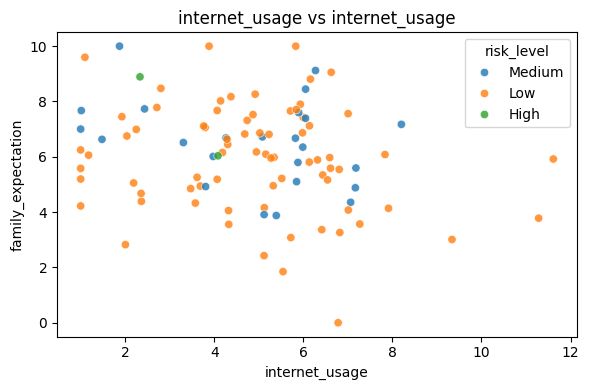

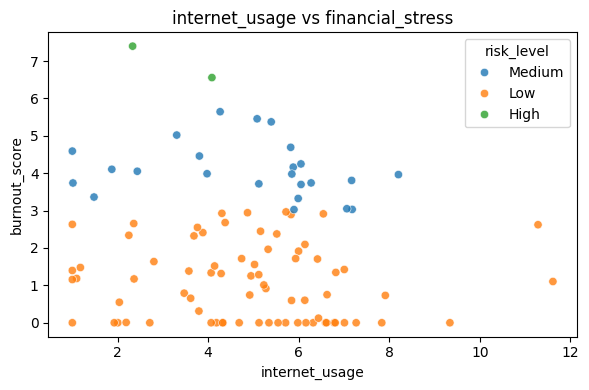

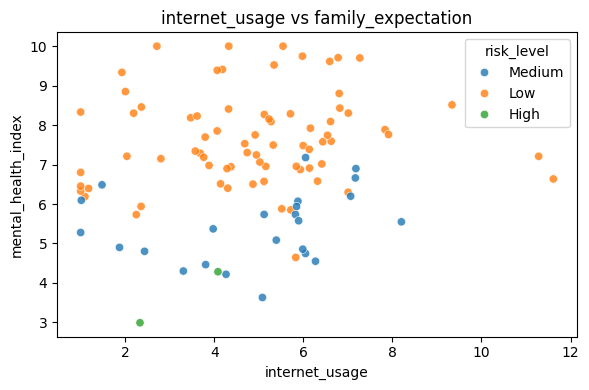

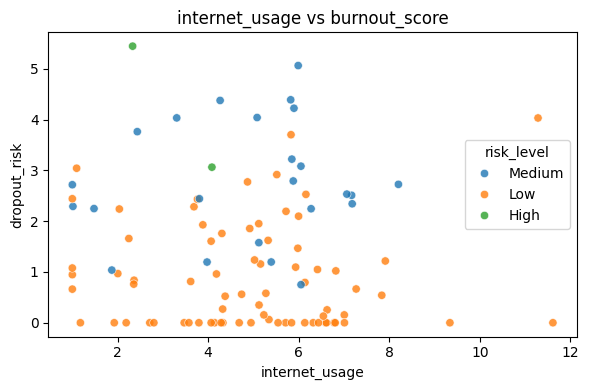

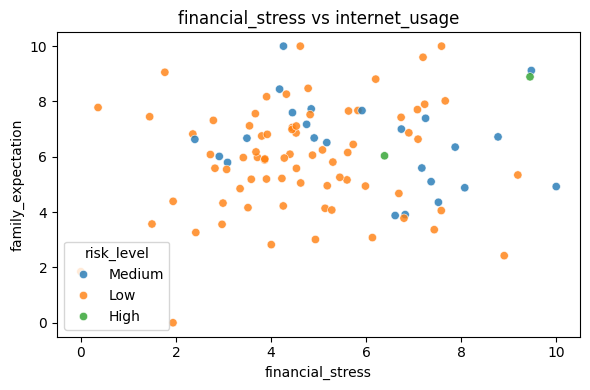

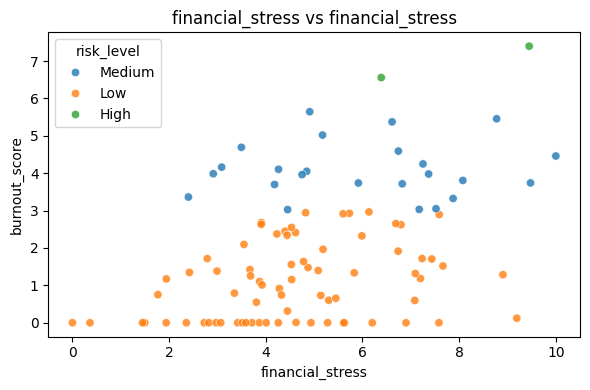

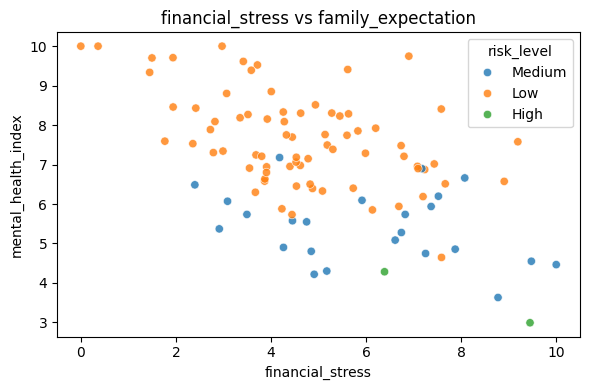

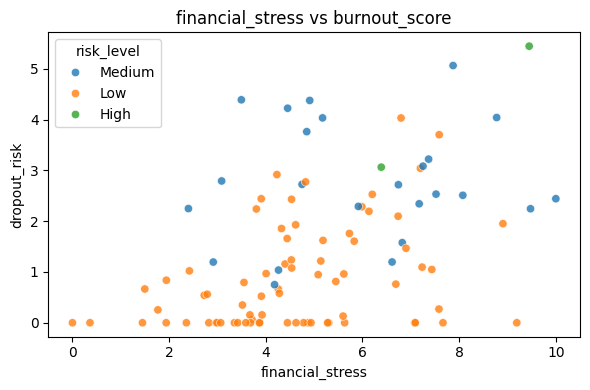

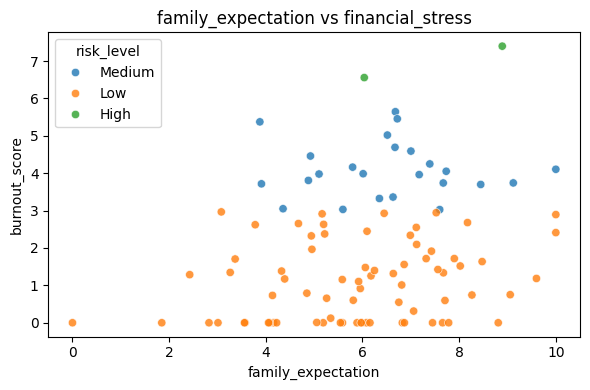

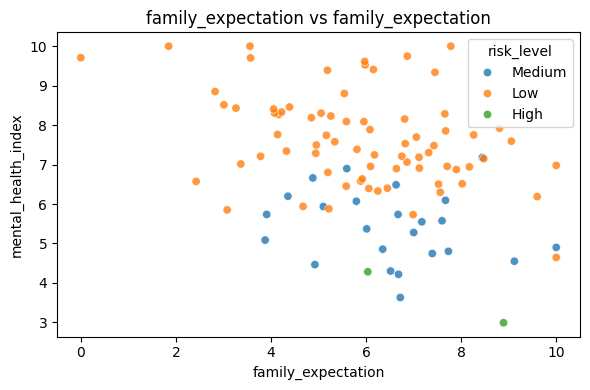

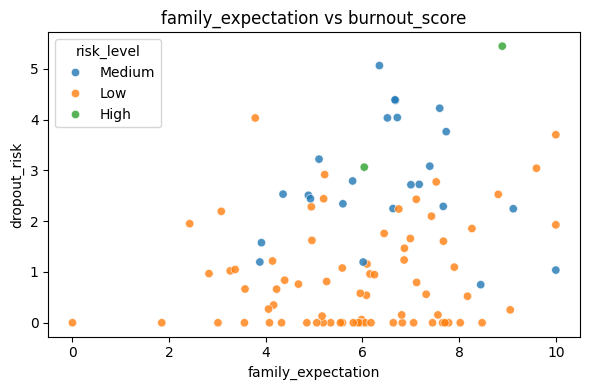

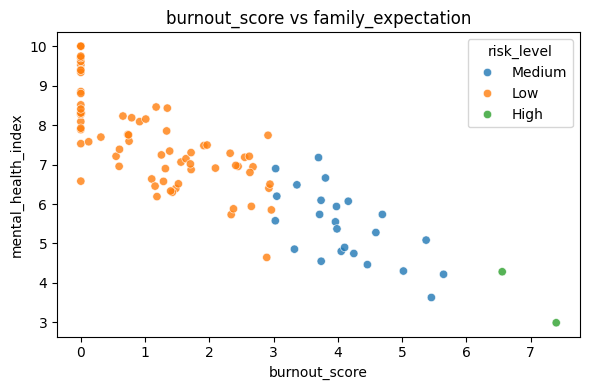

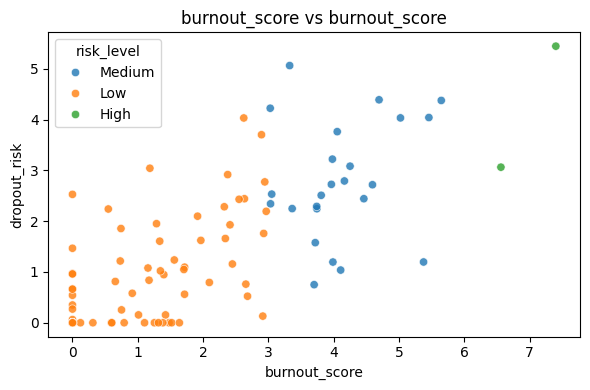

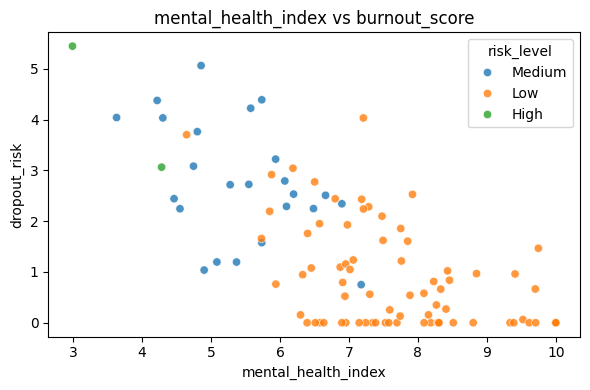

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

MINI_SAMPLE_SIZE = 100
idx = np.random.default_rng(1234).choice(len(df_1m), 
                                         size=MINI_SAMPLE_SIZE, 
                                         replace=False
                                         )
num_df_mini_reduced = df_1m.iloc[idx].copy()

for i in range(len(continuous_feats)):
    for j in range(i+1, len(continuous_feats)):
        fig, ax = plt.subplots(figsize=(6, 4))
        sns.scatterplot(
            data=num_df_mini_reduced,
            x=continuous_feats[i],
            y=continuous_feats[j],
            hue="risk_level",
            alpha=0.8,
            ax=ax
        )
        ax.set_title(f"{continuous_feats[i]} vs {num_feats[j]}")
        plt.tight_layout()
        plt.show()